# NEOK001 Patent Portfolio - Simple Patent Family-Level Analysis
_ABL Bio's Current Patent Portfolio as of Feb 26, 2026_

## <span style="background-color: yellow; color: black;">ABL Bio's Overall Patent Portfolio</span>
Look into patent's ABL Bio owns using Lens.org
- Use search term "ABL BIO INC KR", "ABL BIO INC", "ABL BIO", "ABL BIO INCORPORATED" as owner or applicant name
- For applicant: Results will show 466 Patent Records (Expand by Simple Family), but after selecting simple families, there are 37 results
- For owner: Results will show 437 Patent Records (Expand by Simple Family), but 24 Simple families
- But if you look at Owner section of those applicant sections, you'll see it is because they are NaN
- So just Lens convention, where the owner is the applicant
- There is also no patent simple families that ABL is the owner of but not the applicant -> suggests currently no acquisition-based portfolio growth

> So ABL Bio has 37 simple families ("inventions")


Looking at full picture of ABL Bio's 37 patent families before narrowing to NEOK001-specific filings

This also provides context for where NEOK001 sits within ABL Bio's broader IP strategy

In [2]:
import pandas as pd

own_abl = pd.read_csv("../../data/raw/abl-37.csv")

print(own_abl.shape)
print(own_abl.columns)

(37, 37)
Index(['#', 'Jurisdiction', 'Kind', 'Display Key', 'Lens ID',
       'Publication Date', 'Publication Year', 'Application Number',
       'Application Date', 'Priority Numbers', 'Earliest Priority Date',
       'Title', 'Abstract', 'Applicants', 'Inventors', 'Owners', 'URL',
       'Document Type', 'Has Full Text', 'Cites Patent Count',
       'Cited by Patent Count', 'Simple Family Size', 'Simple Family Members',
       'Simple Family Member Jurisdictions', 'Extended Family Size',
       'Extended Family Members', 'Extended Family Member Jurisdictions',
       'Sequence Count', 'CPC Classifications', 'IPCR Classifications',
       'US Classifications', 'NPL Citation Count',
       'NPL Resolved Citation Count', 'NPL Resolved Lens ID(s)',
       'NPL Resolved External ID(s)', 'NPL Citations', 'Legal Status'],
      dtype='str')


### 1. Timeline of Earliest Priority Date

In [3]:
own_abl['Earliest Priority Date'] = pd.to_datetime(own_abl['Earliest Priority Date'])
own_abl['Year'] = own_abl['Earliest Priority Date'].dt.year

own_abl['Legal Status'].value_counts(dropna=False)

Legal Status
PENDING         22
ACTIVE          12
DISCONTINUED     3
Name: count, dtype: int64

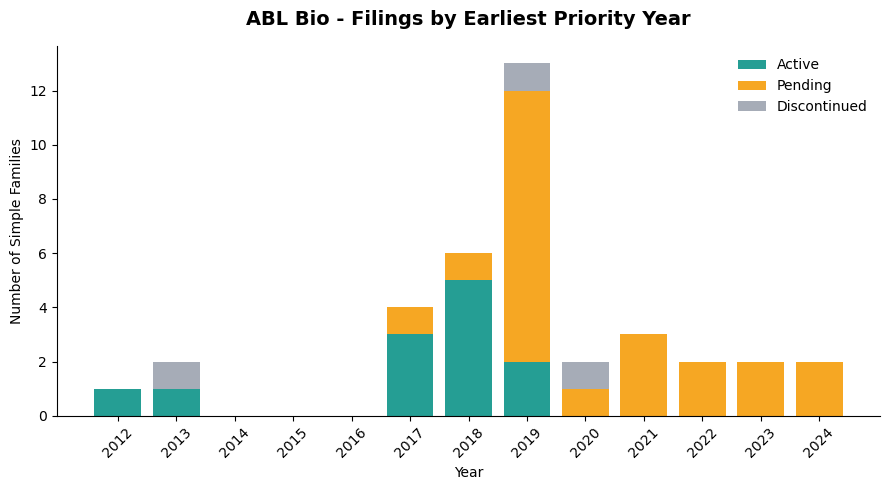

Saved to data/images/05c_ABL_Filings_by_Year.png


In [4]:
import matplotlib.pyplot as plt

# Convert dates
own_abl['Earliest Priority Date'] = pd.to_datetime(own_abl['Earliest Priority Date'])
own_abl['Year'] = own_abl['Earliest Priority Date'].dt.year

# Group properly (include all statuses)
status_yearly = (
    own_abl.groupby(['Year', 'Legal Status'])
    .size()
    .unstack(fill_value=0)
)

all_years = range(own_abl['Year'].min(), own_abl['Year'].max() + 1)
status_yearly = status_yearly.reindex(all_years, fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

bottom_vals = 0

colors = {
    'ACTIVE': '#0D9488',        # teal
    'PENDING': '#F59E0B',       # amber
    'DISCONTINUED': '#9CA3AF'   # grey
}

for status in ['ACTIVE', 'PENDING', 'DISCONTINUED']:
    vals = status_yearly.get(status, 0)
    ax.bar(
        all_years,
        vals,
        bottom=bottom_vals,
        label=status.title(),
        color=colors[status],
        alpha=0.9
    )
    bottom_vals = bottom_vals + vals

ax.set_title("ABL Bio - Filings by Earliest Priority Year",
             fontsize=14, fontweight='bold', pad=15)

ax.set_xlabel("Year")
ax.set_ylabel("Number of Simple Families")
ax.set_xticks(all_years)
ax.tick_params(axis='x', rotation=45)
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../../data/images/05c_ABL_Filings_by_Year.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved to data/images/05c_ABL_Filings_by_Year.png")

In [5]:
print("Total families:", len(own_abl))
print("Stacked total:", status_yearly.sum().sum())

Total families: 37
Stacked total: 37


**Observations from filing timeline:**
- **Filing velocity peaked in 2019** (13 families) - reflects the foundational
  period when ABL Bio's bispecific platforms matured and the NEOK001 antibody
  arms were filed
- **Sustained filing activity through 2024** - ongoing bispecific and ADC
  program development
- **2020-2024 families are predominantly pending** - consistent with standard prosecution timelines (typically 3-5 years from filing
  to grant)
- **Discontinued filings cluster in 2013 and 2020** - earlier families where
  ABL Bio chose not to proceed to national phase or abandoned during
  prosecution


### 2. Legal Status Composition

In [6]:
status_counts = own_abl['Legal Status'].value_counts()

status_summary = pd.DataFrame({
    'Count': status_counts,
    'Percent': round(status_counts / len(own_abl) * 100, 1)
})

status_summary

,Count,Percent
Legal Status,,
PENDING,22,59.5
ACTIVE,12,32.4
DISCONTINUED,3,8.1


### 3. Jurisdiction Coverage

In [7]:
#Jurisdiction Coverage in Major Markets
own_abl['has_us'] = own_abl['Extended Family Member Jurisdictions'].str.contains('US', na=False) #USA
own_abl['has_ep'] = own_abl['Extended Family Member Jurisdictions'].str.contains('EP', na=False) #Europe
own_abl['has_cn'] = own_abl['Extended Family Member Jurisdictions'].str.contains('CN', na=False) #China
own_abl['has_jp'] = own_abl['Extended Family Member Jurisdictions'].str.contains('JP', na=False) #Japan
own_abl['has_wo'] = own_abl['Extended Family Member Jurisdictions'].str.contains('WO', na=False) #PCT

coverage = {
    'US': own_abl['has_us'].sum(),
    'EP': own_abl['has_ep'].sum(),
    'CN': own_abl['has_cn'].sum(),
    'JP': own_abl['has_jp'].sum(),
    'WO': own_abl['has_wo'].sum()

}

print(coverage)

{'US': np.int64(27), 'EP': np.int64(27), 'CN': np.int64(27), 'JP': np.int64(27), 'WO': np.int64(35)}


In [8]:
# Overall Filing Distribution

#split jurisdictions into lists (they are seperated by ;;)
own_abl['jurisdiction_list'] = own_abl['Extended Family Member Jurisdictions'].str.split(';;')

#explode into long format
jur_long = own_abl.explode('jurisdiction_list')

#clean whitespace
jur_long['jurisdiction_list'] = jur_long['jurisdiction_list'].str.strip()

#count frequency
jur_counts = jur_long['jurisdiction_list'].value_counts()

print(jur_counts)

jurisdiction_list
WO    35
KR    30
JP    27
US    27
EP    27
CN    27
CA    22
AU    21
BR    17
MX    13
IL     7
EA     6
ZA     5
CO     4
TW     3
CL     3
PH     3
PE     3
MY     2
SG     2
NZ     2
RU     2
AR     1
PL     1
ES     1
TR     1
Name: count, dtype: int64


/var/folders/ps/9mfd94h1197dqk96m56rhv040000gn/T/ipykernel_12454/2766105897.py:53: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_merged['centroid'] = world_merged.geometry.centroid
/var/folders/ps/9mfd94h1197dqk96m56rhv040000gn/T/ipykernel_12454/2766105897.py:53: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_merged['centroid'] = world_merged.geometry.centroid
/var/folders/ps/9mfd94h1197dqk96m56rhv040000gn/T/ipykernel_12454/2766105897.py:53: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_merged['centroid'] = world_merged.geometry.centroid


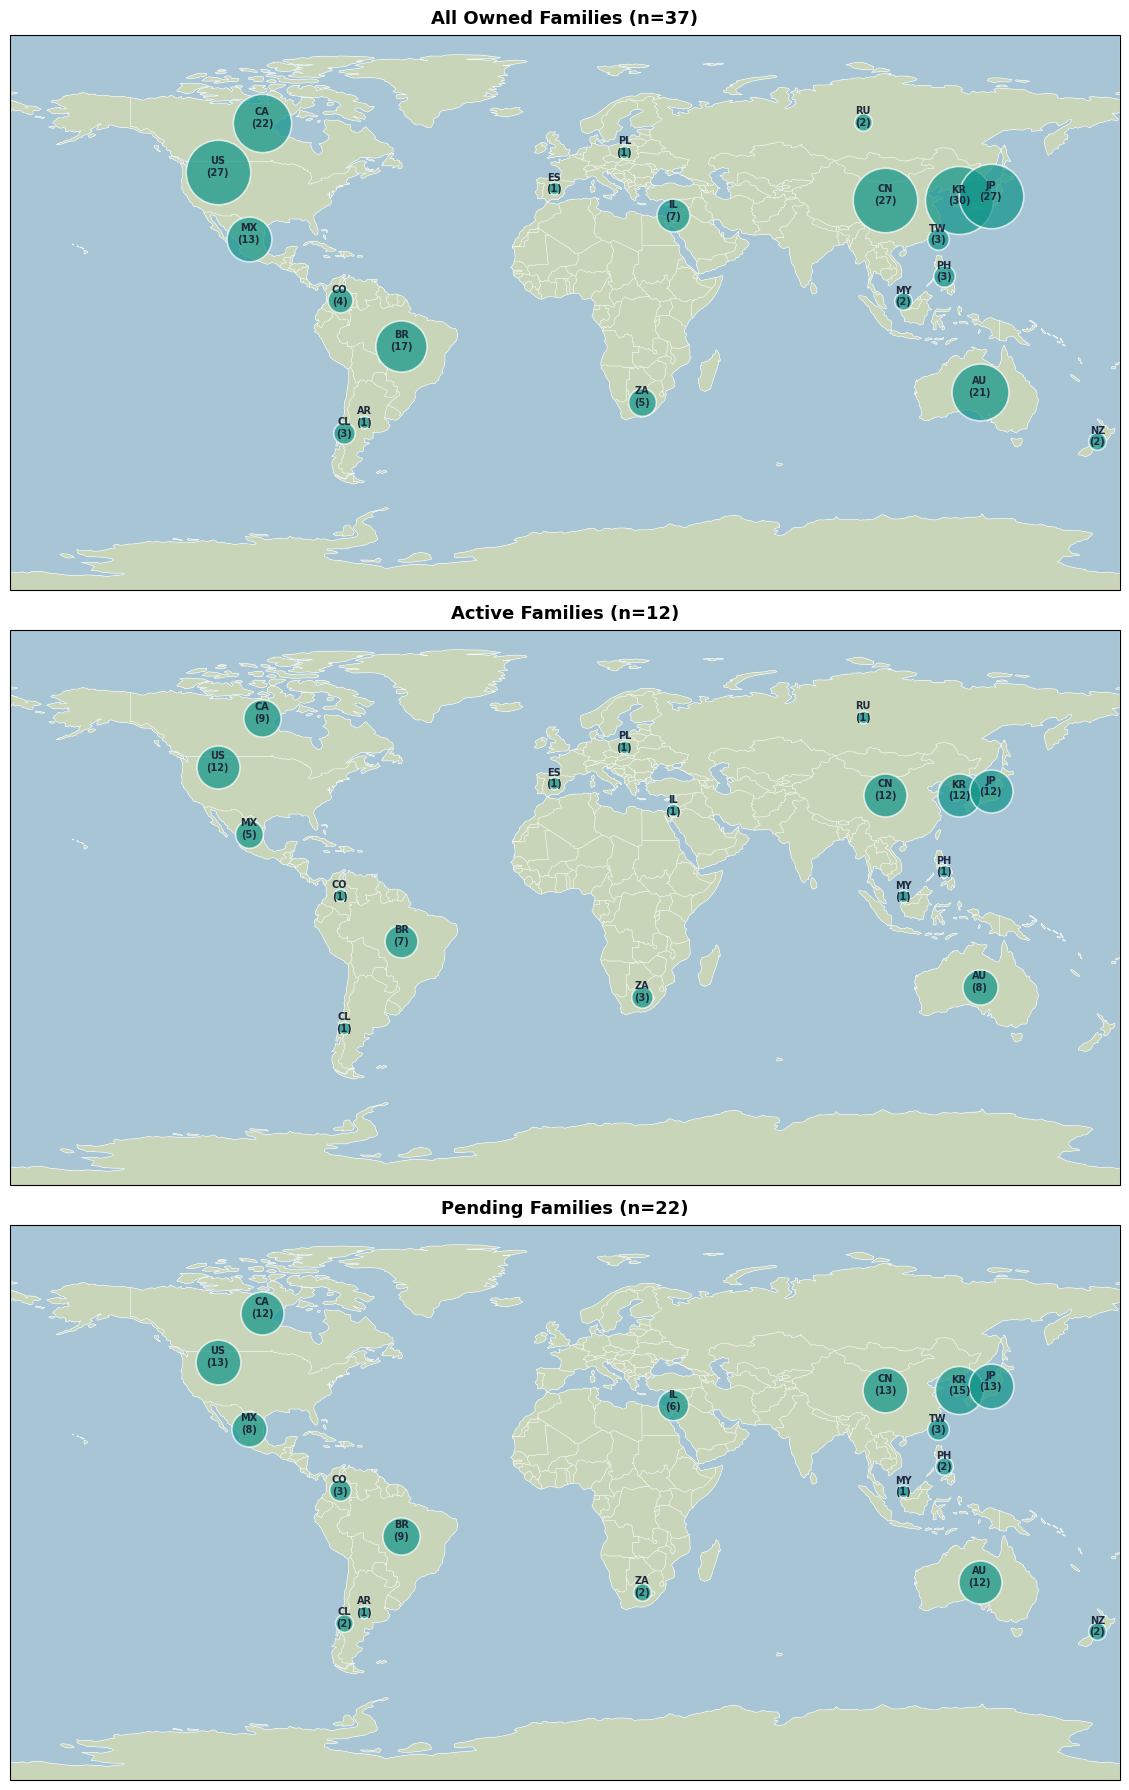

Saved to data/images/05c_ABL_Filings_Jurisdiction.png


In [47]:
# ── JURISDICTION COVERAGE MAP ────────────────────────────────
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

# ISO 2-letter to ISO 3-letter mapping for jurisdictions found in ABL portfolio
juris_to_iso3 = {
    'US': 'USA', 'KR': 'KOR', 'JP': 'JPN', 'CN': 'CHN',
    'CA': 'CAN', 'AU': 'AUS', 'BR': 'BRA', 'IL': 'ISR',
    'MX': 'MEX', 'TW': 'TWN', 'IN': 'IND', 'RU': 'RUS',
    'SG': 'SGP', 'HK': 'HKG', 'NZ': 'NZL', 'ZA': 'ZAF',
    'AR': 'ARG', 'CL': 'CHL', 'CO': 'COL', 'TH': 'THA',
    'VN': 'VNM', 'MY': 'MYS', 'ID': 'IDN', 'PH': 'PHL',
    # EU individual members (only used if EP is excluded and individual filings appear)
    'DE': 'DEU', 'FR': 'FRA', 'GB': 'GBR', 'IT': 'ITA',
    'ES': 'ESP', 'NL': 'NLD', 'CH': 'CHE', 'SE': 'SWE',
    'DK': 'DNK', 'NO': 'NOR', 'FI': 'FIN', 'BE': 'BEL',
    'AT': 'AUT', 'IE': 'IRL', 'PT': 'PRT', 'GR': 'GRC',
    'PL': 'POL', 'CZ': 'CZE', 'HU': 'HUN',
}

# load world geometry (cartopy has built-in Natural Earth)
from cartopy.io import shapereader
shpfilename = shapereader.natural_earth(resolution='110m', category='cultural', name='admin_0_countries')
world = gpd.read_file(shpfilename)

# handle different Natural Earth schemas (ISO_A3 vs ADM0_A3)
if 'ISO_A3' not in world.columns:
    world['ISO_A3'] = world.get('ADM0_A3', world.get('ADM0_ISO', None))

def get_coords(row):
    """Extract centroid coordinates, handling MultiPolygon."""
    try:
        return row['centroid'].x, row['centroid'].y
    except:
        return row.geometry.centroid.x, row.geometry.centroid.y

def make_map(ax, df, title):
    jur_long = df['Extended Family Member Jurisdictions'].str.split(';;').explode().str.strip()
    juris_counts = jur_long.value_counts().reset_index()
    juris_counts.columns = ['Jurisdiction', 'Count']
    juris_counts = juris_counts[~juris_counts['Jurisdiction'].isin(['WO', 'EA', 'EP'])]
    juris_counts['ISO3'] = juris_counts['Jurisdiction'].map(juris_to_iso3)
    juris_counts = juris_counts.dropna(subset=['ISO3'])

    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor='#C8D5B9')
    ax.add_feature(cfeature.OCEAN, facecolor='#A8C5D6')
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor='white')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor='white')

    world_merged = world.merge(juris_counts, left_on='ISO_A3', right_on='ISO3', how='left')
    world_merged['centroid'] = world_merged.geometry.centroid

    for _, row in world_merged.dropna(subset=['Count']).iterrows():
        x, y = get_coords(row)
        size = row['Count'] * 80
        radius_deg = (size ** 0.1) * 0.1
        ax.scatter(x, y, s=size,
                   color='#0D9488', alpha=0.7, zorder=5,
                   edgecolors='white', linewidth=1.2,
                   transform=ccrs.PlateCarree())
        ax.text(x, y + radius_deg - 1.5,
                f"{row['Jurisdiction']}\n({int(row['Count'])})",
                ha='center', fontsize=7, fontweight='bold',
                color='#1E293B', zorder=6,
                transform=ccrs.PlateCarree())

    ax.set_title(title, fontsize=13, fontweight='bold', pad=8)

active = own_abl[own_abl['Legal Status'] == 'ACTIVE']
pending = own_abl[own_abl['Legal Status'] == 'PENDING']

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 18),
                                     subplot_kw={'projection': ccrs.PlateCarree()})
make_map(ax1, own_abl, f"All Owned Families (n={len(own_abl)})")
make_map(ax2, active,  f"Active Families (n={len(active)})")
make_map(ax3, pending, f"Pending Families (n={len(pending)})")

plt.tight_layout()
plt.savefig('../../data/images/05c_ABL_Filings_Jurisdiction.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved to data/images/05c_ABL_Filings_Jurisdiction.png")

### 4. Key Inventors

In [23]:
own_abl['Inventors'].head()

0    AHN JINHYUNG;;AN SUNGWON;;KIM DONGIN;;SUNG EUN...
1    PARK EUNYOUNG;;LEE YANGSOON;;CHUNG HYEJIN;;JUN...
2    PARK EUNYOUNG;;LEE YANGSOON;;JUNG UIJUNG;;KIM ...
3    SONG DAEHAE;;PAK YOUNGDON;;JUNG JINWON;;HONG J...
4    AN SUNGWON;;AHN JINHYUNG;;SUNG BYUNGJE;;KIM DO...
Name: Inventors, dtype: str

In [24]:
own_inv = (
    own_abl
    .assign(Inventors=own_abl['Inventors'].str.split(';;'))
    .explode('Inventors')
)

own_inv['Inventors'] = own_inv['Inventors'].str.strip()

owner_counts = own_inv['Inventors'].value_counts()

owner_counts.head(10)

Inventors
JUNG JINWON      16
LEE YANGSOON     16
SUNG BYUNGJE     15
KIM JUHEE        14
PARK KYUNGJIN    13
AHN JINHYUNG     12
KIM YEUNJU       12
PAK YOUNGDON     12
EOM JAEHYUN      11
CHUNG HYEJIN     11
Name: count, dtype: int64

**Observation:** ABL Bio has approximately 4-5 core inventors appearing in ~40-50% of ABL Bio's owned simple families:
- JUNG JINWON
- LEE YANGSOON
- SUNG BYUNGJE
- KIM JU EON
- PARK YOUNGWOOK


#### <u>Inventor-Linked Search (Outside ABL Bio Ownership)</u>

**Trying to also find if there's any hidden patents, named to person but not company (exploratory; for my own curiosity)**

Due to time and scope of project, I just looked at the top 5 inventors; So inputting into Lens.org:
```
(inventor.name:"JUNG JINWON" OR 
inventor.name:"LEE YANGSOON" OR 
inventor.name:"SUNG BYUNGJE" OR  
inventor.name:"KIM JUHEE" OR
inventor.name:"PARK KYUNGJIN")  
AND NOT (applicant.name:"ABL Bio"  
OR applicant.name:"ABLBIO"
OR owner_all.name:"ABL Bio"
OR owner_all.name:"ABLBIO")
AND (class_cpc.symbol:C07K16/*  
OR class_cpc.symbol:C07K2317/*  
OR class_cpc.symbol:A61K39/*  
OR class_cpc.symbol:A61K47/*)
```

But also to limit mis-identified inventors (due to same name), will try narrow it down to:  
- C07K16/* → antibodies
- C07K2317/* → conjugates involving peptides/antibodies
- A61K39/* → medicinal antibodies
- A61K47/* → formulations & carriers (relevant for ADC linkers)

In [43]:
inv_ext = pd.read_csv("../../data/raw/inventor-no-abl.csv")

print(f"Exploratory filings returned: {len(inv_ext)}")
print(f"Unique simple family IDs:     {inv_ext['Simple Family Members'].nunique()}\n")

print("Legal status breakdown:")
print(inv_ext['Legal Status'].value_counts(), "\n")

print("Applicant distribution:")
print(inv_ext['Applicants'].value_counts().head(10))

Exploratory filings returned: 10
Unique simple family IDs:     10

Legal status breakdown:
Legal Status
PENDING    9
ACTIVE     1
Name: count, dtype: int64 

Applicant distribution:
Applicants
YUHAN CORP                                                                                                                                                                                   3
TSD LIFE SCIENCES CO LTD                                                                                                                                                                     1
LEGOCHEM BIOSCIENCES INC                                                                                                                                                                     1
I MAB BIOPHARMA US LTD                                                                                                                                                                       1
HANWHA CHEMICAL CORP;;LEE JUNGTAE;;MOON KYU

In [44]:
# Drill into the LegoChem-assigned filing (they co-own patent to CS5001 with ABL) to confirm relationship 
lgc = inv_ext[inv_ext['Applicants'].str.contains("LEGOCHEM", na=False)].iloc[0]

LCB71_KNOWN_ID = "180-068-866-368-876"  # A co-owned ABL+LegoChem record for CS5001

with pd.option_context('display.max_colwidth', None):
    print(f"Lens ID:            {lgc['Lens ID']}")
    print(f"Title:              {lgc['Title']}")
    print(f"Jurisdiction:       {lgc['Jurisdiction']}")
    print(f"Priority Date:      {lgc['Earliest Priority Date']}")
    print(f"Legal Status:       {lgc['Legal Status']}")
    print(f"Applicants:         {lgc['Applicants']}")
    print(f"Owners:             {lgc['Owners']}")
    print(f"Simple Family Size: {lgc['Simple Family Size']}")
    print(f"\nSibling LCB71 record ({LCB71_KNOWN_ID}) present in family? "
          f"{LCB71_KNOWN_ID in str(lgc['Simple Family Members'])}")

Lens ID:            027-210-615-663-296
Title:              ANTIBODY-DRUG CONJUGATE COMPRISING ANTIBODY AGAINST HUMAN ROR1, AND USE FOR THE SAME.
Jurisdiction:       MX
Priority Date:      2019-09-04
Legal Status:       PENDING
Applicants:         LEGOCHEM BIOSCIENCES INC
Owners:             nan
Simple Family Size: 28

Sibling LCB71 record (180-068-866-368-876) present in family? True


**Observations**

The 10 simple patent families seem to be in three groups

**1. Pre-ABL Bio employment history (Hanwha Chemical; 2 filings)**
ABL Bio was founded in 2016 as effectively a spinout of the Hanwha Chemical Bio Division 
— ABL Bio CEO Lee Sang-hoon was Head of the Bio Division at Hanwha Chemical, and several key ABL scientists (including CRO Weon Kyoo You) transitioned from the same group
- Co-inventor **SUNG BYUNGJE** authored antibody patents under Hanwha ownership during this prior-employment period
- Not relevant patents to ABL206/NEOK001

**2. Sibling filing in the LCB71/CS5001 family (LegoChem Biosciences; 1 filing)**
- Lens ID `027-210-615-663-296`
- *"Antibody-Drug Conjugate Comprising Antibody Against Human ROR1, and Use for the Same"* 
- Jurisdiction: MX; Status: PENDING; Applicant: LegoChem Biosciences Inc; Priority: 2019-09-04

Confirmed as the Mexican national phase entry within the LCB71/CS5001 patent family, which is co-owned by ABL Bio and LigaChem (formerly LegoChem) Biosciences and licensed to CStone Pharmaceuticals
- The inventor list is identical to the ABL co-owned sibling record `180-068-866-368-876`, and that sibling appears in this record's `Simple Family Members` list
- ABL Bio co-assignment was formalized on 2020-10-05 (concurrent with the CStone licensing deal)
- ABL's absence on the Mexican sibling most likely reflects a potential delay in assignment record across national patent registers rather than a true ownership difference

**3. Probable homonym matches (Yuhan Corp, I-Mab Biopharma, TSD Life Sciences; 7 filings)**
Given the high prevalence of the surname/given-name combinations in Korean inventor records (and the absence of target-class overlap with ABL's bispecific antibody and ADC portfolio), these are most likely other individuals who share a name with ABL personnel rather than potential hidden cross-assignments. 

Not pursued further given project scope.

---

## <span style="background-color: yellow; color: black;">ABL Bio's Patent Family Composition</span>

Continuing down the patent portfolio analysis now, I next manual annotated all 37 families by looking at CPC, title and the claims

In [18]:
for i, row in own_abl.iterrows():
    print(f"\n--- Family {i+1} ---")
    print(row['Legal Status'])
    print("Title:")
    print(row['Title'])
    print("\nLens ID:")
    print(row['Lens ID'])
    print("\nCPC:")
    print(row['CPC Classifications'])


--- Family 1 ---
PENDING
Title:
ANTIBODIES FOR TREATING ALPHA-SYNUCLEINOPATHIES

Lens ID:
141-040-150-695-864

CPC:
C07K16/18;;C07K2317/24;;C07K16/2863;;A61P25/00;;A61K2039/505;;C07K2317/31;;A61P25/16;;C07K16/18;;C07K2317/24;;C07K2317/31;;C07K16/2863;;C07K2317/622;;C07K2317/92;;C07K16/18;;A61K2039/505;;C07K16/2863;;C07K2317/24;;C07K2317/31;;C07K2317/35;;C07K2317/565;;C07K2317/567;;C07K2317/622;;C07K2317/92;;A61P25/16;;C07K16/18;;C07K16/2863;;A61P25/00;;C07K2317/31;;C07K2317/35;;C07K2317/24;;C07K2317/92;;C07K2317/622;;C07K2317/565;;C07K2317/567;;A61K2039/505;;C07K16/18;;C07K16/2863;;A61P25/16;;A61K2039/505;;C07K2317/24;;C07K2317/92;;C07K2317/567;;C07K2317/622;;C07K2317/31;;C07K2317/35;;C07K2317/565

--- Family 2 ---
ACTIVE
Title:
ANTI-4-1BB ANTIBODY AND USE THEREOF

Lens ID:
084-986-690-232-010

CPC:
A61P35/00;;C07K2317/64;;C07K2317/622;;C07K16/2827;;C07K16/2878;;C07K2317/31;;C07K2317/24;;C07K2317/34;;C07K2317/92;;C07K2317/21;;C07K2317/75;;A61K2039/505;;A61K2039/505;;A61P35/00;;C07K16/

#### **The distribution looks like:**
<u>1) Purely Antibody Composition Patents:</u> (n=11)
- Families 1, 2, 6, 8, 10, 11, 12, 15, 22, 27, 31,
- Dominant CPC of C07K16/* (Immunoglobulins, e.g., monoclonal or polyclonal antibodies)
- For DLL4, 4-1BB, BCMA, alpha-synuclein, B7-H3, ROR1, CLL-1 

<u>2) Bi-specific Antibody Composition Patents:</u> (n=16)
- Families 3, 5, 7, 13, 14, 23, 24, 25, 26, 17, 18, 19, 20, 29, 30, 35
- For DLL4/VEGF, Alpha-SYN/IGF1R, PD-L1/LAG3, B7-H4/4-1BB, BCMA/4-1BB, TIGIT/4-1BB, LILRB4/4-1BB, HER2/4-1BB, EGFR/4-1BB, ROR1/4-1BB, ROR1/B7-H3, PD-L1/B7-H3, or Claudin 18.2/4-1BB

<u>3) ADC Composition Patents (Conjugate):</u> (n=6)
- Families 9 (Discontinued), 16, 28 (Discontinued), 32 (Discontinued), 33, 34
- Family 9 is **Payload-centric** patent: Cyclopropabenzindole (CBI) cytotocix payload linked to a galactose trigger moiety (breadth in antibody, target)
- Family 16 is **Full ADC** composition patent: Antibody-drug conjugates targeting ROR1, including active metabolites and pharmaceutical compositions for treatment of ROR1-overexpressing cancers
- Family 28 is a **Conjugated Linker** patent: Conjugating any drug to the N-terminal α-amine of any antibody via a linker with a reactive aldehyde (breadth in antibody, payload, target)
- Family 32 is **Full ADC** composition patent: Sequence-defined anti-ROR1 antibody conjugated via cleavable glucuronide/peptide linker architectures, including site-specific conjugation and branched dual-payload designs
- Family 33 is **Full ADC** composition patent: ROR1/B7-H3 bispecific antibody conjugated via cleavable glucuronide and peptide-based linker architectures, including site-specific C-terminal engineering and branched multi-payload designs
- Family 34 is **Full ADC** composition patent: Similar to above (Family 33) but with a monospecific platform, using anti-B7-H3 antibody


<u> 4) Clinical Filing:</u> (n=3)
- Family 21, 36, 37
- Family 21, with title "A method of treating a solid tumor" -> Summary is treating solid tumors using a CLDN18.2 bispecific antibody, with specified dosing ranges, schedules, routes, and patient populations (tumor types, advanced/metastatic setting)
- Family 36, with title "Combination of anti-claudin 18.2/anti-4-1bb antibodies and second therapeutic agent in treatment of cancer" -> Summary is use of a CLDN18.2/4-1BB bispecific antibody in combination with chemotherapeutic agents and/or immune checkpoint inhibitors (e.g., fluoropyrimidines, platinum agents, PD-1/PD-L1 antibodies), with specified dosing ranges, schedules, routes, and patient populations (tumor types, gastric cancer)
- Family 37, with title "Methods of treating cancer by administering anti-pd-l1/anti-4-1bb bispecific antibodies" -> Summary is treating advanced or metastatic solid tumors using a PD-L1/4-1BB bispecific antibody, with specified dosing ranges, schedules, route (IV), and patient populations (previously treated, relapsed, refractory cancers)


<u>5) CMC Patent:</u> (n=1)
- Family 4, with title "Method for Purifying Biologically Active Peptide by Using Protein A Affinity Chromatography"
- Summary is improved purification process for Fc-containing biologics using differential Protein A binding based on VH3 domain number
    - Wild-type protein A binds to Fc region of IgG (primary) as well as VH3 family variable domain (secondary). They determined that Protein A binding strength increases with more VH3 domains in the molecule
    - So instead of mutating Fc to artifically change affinity, use stepwise elution that will start with mild pH and then decrease -> molecules with weaker Protein A affinity elute first, followed by stronger binders at lower pH. This enables separation of highly similar antibody species


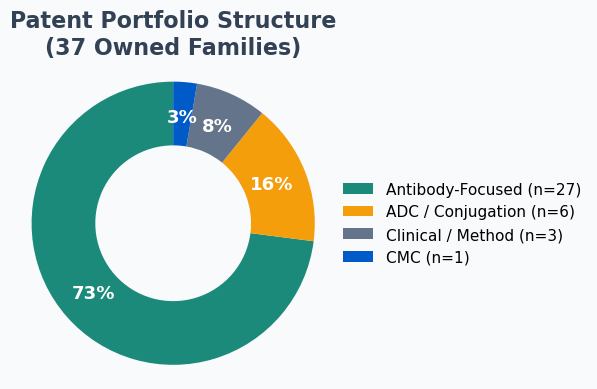

In [38]:
import matplotlib.pyplot as plt

# Data
labels = [
    "Antibody-Focused (n=27)",
    "ADC / Conjugation (n=6)",
    "Clinical / Method (n=3)",
    "CMC (n=1)"
]

sizes = [27, 6, 3, 1]

# Colors
colors = [
    "#1B8A7A",   # dark navy (core)
    "#F59E0B",   # orange (ADC)
    "#64748B",   # slate (clinical)
    "#005BC9"    # blue (CMC)
]

fig, ax = plt.subplots(figsize=(6,4))
#background color
bg_color = "#f8fafc"
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

wedges, texts, autotexts = ax.pie(
    sizes,
    colors=colors,
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'width':0.45},
    textprops={'color': 'white',
               'weight': 'bold',
               'fontsize': 13}
)

ax.set_title(
    "Patent Portfolio Structure\n(37 Owned Families)",
    fontsize=16,
    weight='bold',
    color="#334155",
    pad=10,
)

# Equal aspect ratio to make it circular
ax.axis('equal')

# legend
ax.legend(
    wedges,
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=11
)

plt.tight_layout()
plt.savefig('../../data/images/05c_ABL_Distribution.png',
            dpi=150, bbox_inches='tight', facecolor='white',
            pad_inches=0.2)  
plt.show()

---

## <span style="background-color: yellow; color: black;">Patents related to NEOK001</span>

Examining titles and composition annotations, 7 families seem NEOK001-relevant:

| Family | Title | Lens ID | Layer | 
|--------|-------|---------|-------|
| 8 | Anti-B7-H3 antibody and use thereof | 040-924-461-597-34X | Antibody Arms | 
| 10 | Anti-ROR1 antibody and use thereof | 132-024-389-417-675 | Antibody Arms | 
| 24 | Anti-ROR1 antibody, bispecific antibody comprising same, and uses thereof | 085-693-226-467-972 | Bispecific Format | 
| 16 | Antibody-drug conjugate comprising antibody against human ROR1 | 130-301-980-653-720 | ROR1 ADC (CS5001-focused) | 
| 34 | Antibody-drug conjugate comprising anti-B7-H3 antibody and its use | 051-245-872-017-682 | B7-H3 ADC | 
| 29 | Antibody that binds to ROR1 and B7-H3, antibody-drug conjugate containing same | 063-625-262-975-971 | Core Bispecific ADC (sequence-specific) |
| 33 | ROR1 and B7-H3 binding antibody-drug conjugate and use thereof | 141-269-859-464-516 | Core Bispecific ADC (broadest genus) |

_Note: Family numbers are just based on row position in the Lens.org CSV export._

**Protection layers summary:**
- **Antibody Arms** (F8, F10) 
- **Bispecific Format** (F24) 
- **ROR1 ADC** (F16)
- **B7-H3 ADC** (F34) 
- **Core Bispecific ADC** (F29, F33) 


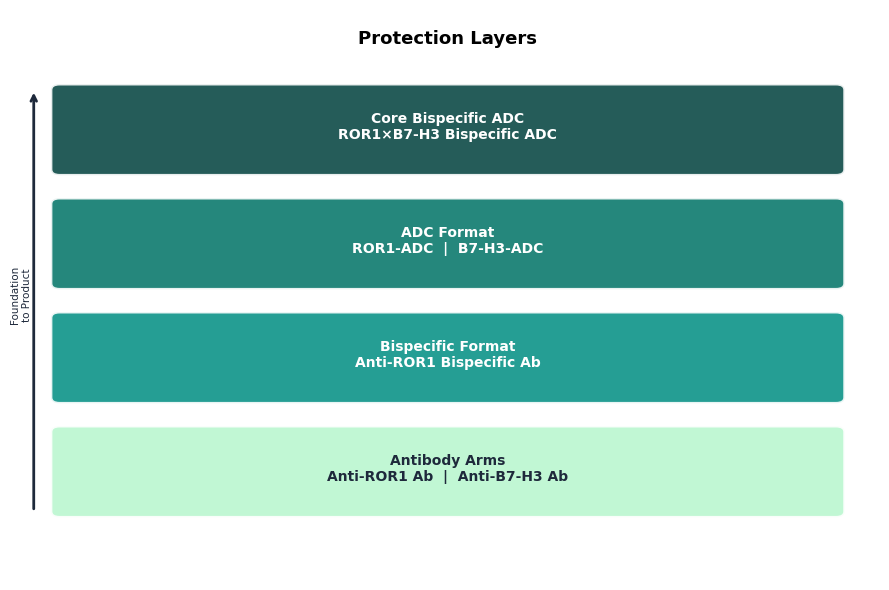

In [39]:
# Visualization of potential IP structure
import matplotlib.patches as mpatches

layer_colors = {
    'Antibody Arms':       '#BBF7D0',  # NEOK_LIGHT
    'Bispecific Format':   '#0D9488',  # NEOK_TEAL
    'ADC Format':          '#0D7A6E',  # NEOK_MID
    'Core Bispecific ADC': '#0D4A47',  # NEOK_DARK
}

fig1, ax1 = plt.subplots(figsize=(9, 6))
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')

layers = [
    ('Antibody Arms', 'Anti-ROR1 Ab  |  Anti-B7-H3 Ab', 1.2),
    ('Bispecific Format', 'Anti-ROR1 Bispecific Ab', 3.2),
    ('ADC Format', 'ROR1-ADC  |  B7-H3-ADC', 5.2),
    ('Core Bispecific ADC', 'ROR1×B7-H3 Bispecific ADC', 7.2),
]

for layer, desc, y in layers:
    color = layer_colors[layer]
    rect = mpatches.FancyBboxPatch((0.5, y), 9, 1.4,
                                    boxstyle="round,pad=0.1",
                                    facecolor=color, alpha=0.9,
                                    edgecolor='white', linewidth=2)
    ax1.add_patch(rect)
    text_color = '#1E293B' if layer == 'Antibody Arms' else 'white'
    ax1.text(5, y + 0.75, f"{layer}\n{desc}",
             ha='center', va='center', fontsize=10,
             fontweight='bold', color=text_color)

# arrow bottom to top
ax1.annotate('', xy=(0.2, 8.6), xytext=(0.2, 1.2),
             arrowprops=dict(arrowstyle='->', color='#1E293B', lw=2))
ax1.text(0.05, 5, 'Foundation\nto Product', fontsize=7.5,
         color='#1E293B', va='center', ha='center', rotation=90)

ax1.text(5, 9.5, 'Protection Layers',
         ha='center', va='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [40]:
neok001_families = {
    'Core Bispecific ADC': [
        '063-625-262-975-971',  # Family 29 - ROR1+B7H3 ADC
        '141-269-859-464-516',  # Family 33 - ROR1+B7H3 ADC linker
    ],
    'ADC Format': [
        '130-301-980-653-720',  # Family 16 - ROR1 ADC
        '051-245-872-017-682',  # Family 34 - B7H3 ADC
    ],
    'Bispecific Format': [
        '085-693-226-467-972',  # Family 24 - ROR1 bispecific
    ],
    'Antibody Arms': [
        '132-024-389-417-675',  # Family 10 - anti-ROR1
        '040-924-461-597-34X',  # Family 8  - anti-B7H3
    ]
}

rows = []
for layer, ids in neok001_families.items():
    for lid in ids:
        rows.append({'lens_id': lid, 'layer': layer})

neok001_df = pd.DataFrame(rows)

abl_cols = own_abl[['Lens ID', 'Title', 'Legal Status', 'Earliest Priority Date']].copy()
abl_cols.columns = ['lens_id', 'title', 'status', 'priority_date']
abl_cols['priority_date'] = pd.to_datetime(abl_cols['priority_date'])
abl_cols['expiry_date'] = abl_cols['priority_date'] + pd.DateOffset(years=20)
abl_cols['years_to_expiry'] = (abl_cols['expiry_date'] - pd.Timestamp.now()).dt.days / 365

neok001_df = neok001_df.merge(abl_cols, on='lens_id', how='left')
neok001_df['short_title'] = neok001_df['title'].str[:45]

print(neok001_df[['layer', 'short_title', 'status', 'priority_date', 'expiry_date', 'years_to_expiry']])

                 layer                                    short_title  \
0  Core Bispecific ADC  ANTIBODY THAT BINDS TO ROR1 AND B7-H3, ANTIBO   
1  Core Bispecific ADC  ROR1 and B7-H3 binding antibody-drug conjugat   
2           ADC Format  Conjugado de anticorpo-fármaco compreendendo    
3           ADC Format  -B7-H3 - Antibody-drug conjugate comprising a   
4    Bispecific Format  ANTI-ROR1 ANTIBODY, BISPECIFIC ANTIBODY COMPR   
5        Antibody Arms             Anti-ROR1 antibody and use thereof   
6        Antibody Arms            Anti-B7-H3 antibody and use thereof   

    status priority_date expiry_date  years_to_expiry  
0  PENDING    2019-11-21  2039-11-21        13.575342  
1  PENDING    2021-05-21  2041-05-21        15.073973  
2  PENDING    2019-09-04  2039-09-04        13.361644  
3  PENDING    2019-11-22  2039-11-22        13.578082  
4  PENDING    2022-07-15  2042-07-15        16.224658  
5   ACTIVE    2018-05-23  2038-05-23        12.076712  
6   ACTIVE    2018-05-2

### 1. Looking further into status

In [13]:
#There are multiple pending, that are way past PCT deadlines 
#Just to double check and also check current status/jurisdiction of these families

neok001_ids = [
    '063-625-262-975-971',  # Family 29
    '141-269-859-464-516',  # Family 33
    '130-301-980-653-720',  # Family 16
    '051-245-872-017-682',  # Family 34
    '085-693-226-467-972',  # Family 24
    '132-024-389-417-675',  # Family 10
    '040-924-461-597-34X',  # Family 8
]

pct = own_abl[own_abl['Lens ID'].isin(neok001_ids)][
    ['Lens ID', 'Title', 'Legal Status', 'Earliest Priority Date', 
     'Simple Family Member Jurisdictions']
].copy()

pct['priority_date'] = pd.to_datetime(pct['Earliest Priority Date'])
pct['pct_deadline'] = pct['priority_date'] + pd.DateOffset(months=30)
pct['months_remaining'] = ((pct['pct_deadline'] - pd.Timestamp.now()).dt.days / 30).round(1)
pct['status'] = pct['months_remaining'].apply(lambda x: 
    '🔴 PASSED' if x < 0 else 
    '🟡 URGENT (<6mo)' if x < 6 else 
    '🟢 OK')

print(pct[['Title', 'Legal Status', 'priority_date', 'pct_deadline', 
           'months_remaining', 'status', 'Simple Family Member Jurisdictions']].to_string())

                                                                                              Title Legal Status priority_date pct_deadline  months_remaining    status              Simple Family Member Jurisdictions
7                                                               Anti-B7-H3 antibody and use thereof       ACTIVE    2018-05-24   2020-11-24             -66.0  🔴 PASSED                          EP;;WO;;JP;;KR;;US;;CN
9                                                                Anti-ROR1 antibody and use thereof       ACTIVE    2018-05-23   2020-11-23             -66.0  🔴 PASSED                          EP;;WO;;JP;;KR;;US;;CN
15     Conjugado de anticorpo-fármaco compreendendo anticorpo contra ror1 humano e uso para o mesmo      PENDING    2019-09-04   2022-03-04             -50.5  🔴 PASSED  CA;;AU;;EP;;WO;;JP;;KR;;BR;;CN;;US;;TW;;IL;;MX
23                        ANTI-ROR1 ANTIBODY, BISPECIFIC ANTIBODY COMPRISING SAME, AND USES THEREOF      PENDING    2022-07-15   2025-01

All 7 families have passed their PCT 30-month deadline. For those active, that's expected and means the company has made their national phase entry decisions.
- PCT deadline passing just means they can no longer use the PCT route to enter new countries cheaply
- But they can use direct national filings; file directly in the individual countries they want coverage in
- WO/PCT publication still exists and establishes prior art

<u>In terms of family member jurisdictions:</u> 

**Well covered:**
- Family 8 & 10 (Antibody Arms) — EP, JP, KR, US, CN 
- Family 16 (ROR1 ADC) — CA, AU, EP, JP, KR, BR, CN, US, TW, IL, MX 
- Family 24 (Bispecific) — CA, AU, EP, JP, KR, US, CN 

**Just WO or limited coverage:**
- Family 29 (Core NEOK001) — WO only 
- Family 33 (Core NEOK001 linker) — KR, TW
- Family 34 (B7H3 ADC) — KR only

In [18]:
# get all unique jurisdictions across NEOK001 families
all_jurs = set()
for lid in neok001_ids:
    jur = own_abl[own_abl['Lens ID'] == lid]['Simple Family Member Jurisdictions'].values[0]
    jurs = [j.strip() for j in jur.split(';;') if j.strip() != '']  # removed WO from exclusion
    all_jurs.update(jurs)

print(sorted(all_jurs))

['AU', 'BR', 'CA', 'CN', 'EP', 'IL', 'JP', 'KR', 'MX', 'TW', 'US', 'WO']


In [20]:
# key markets to check
key_markets = ['US', 'EP', 'CN', 'JP', 'KR', 'CA', 'AU', 'BR', 'TW', 'IL', 'MX', 'WO']

# build coverage matrix
coverage = []
for _, row in neok001_df.iterrows():
    jur = own_abl[own_abl['Lens ID'] == row['lens_id']]['Simple Family Member Jurisdictions'].values[0]
    jurs = [j.strip() for j in jur.split(';;') if j.strip() != '']  # keep WO now
    entry = {'family': row['title'], 'layer': row['layer']}
    for market in key_markets:
        entry[market] = 1 if market in jurs else 0
    coverage.append(entry)

cov_df = pd.DataFrame(coverage)

# reorder
layer_order = ['Antibody Arms', 'Bispecific Format', 'ADC Format', 'Core Bispecific ADC']
cov_df['layer_order'] = cov_df['layer'].map({l: i for i, l in enumerate(layer_order)})
cov_df_sorted = cov_df.sort_values('layer_order').reset_index(drop=True)

print(cov_df_sorted[['family'] + key_markets])

                                              family  US  EP  CN  JP  KR  CA  \
0                 Anti-ROR1 antibody and use thereof   1   1   1   1   1   0   
1                Anti-B7-H3 antibody and use thereof   1   1   1   1   1   0   
2  ANTI-ROR1 ANTIBODY, BISPECIFIC ANTIBODY COMPRI...   1   1   1   1   1   1   
3  Conjugado de anticorpo-fármaco compreendendo a...   1   1   1   1   1   1   
4  -B7-H3 - Antibody-drug conjugate comprising an...   0   0   0   0   1   0   
5  ANTIBODY THAT BINDS TO ROR1 AND B7-H3, ANTIBOD...   0   0   0   0   0   0   
6  ROR1 and B7-H3 binding antibody-drug conjugate...   0   0   0   0   1   0   

   AU  BR  TW  IL  MX  WO  
0   0   0   0   0   0   1  
1   0   0   0   0   0   1  
2   1   0   0   0   0   1  
3   1   1   1   1   1   1  
4   0   0   0   0   0   0  
5   0   0   0   0   0   1  
6   0   0   1   0   0   1  


### 2. Look at each jurisdictions 
The status from The Lens seem to be just based on the **representative patent**, so actually need to manually check each simple family member jurisdiction's status


##### Family 8 — Anti-B7-H3 antibody and use thereof
**Lens ID:** 040-924-461-597-34X  
**Layer:** Antibody Arms  
**Protects:** B7-H3 antibody arm  
**Co-assignee:** ABL Bio only

| Application | Jurisdiction | Filing Date | Status |
|-------------|-------------|-------------|--------|
| PCT/KR2018/005854 | WO | 2018-05-23 | Ceased (expected — superseded by 2019 PCT) |
| PCT/KR2019/006213 | WO | 2019-05-23 | Ceased (expected — national phase entered) |
| KR1020207037054A | KR | 2019-05-23 | **Active** |
| EP19806701.9A | EP | 2019-05-23 | Pending |
| CN201980034456.0A | CN | 2019-05-23 | **Active** |
| US17/057,646 | US | 2019-05-23 | **Active** (= US11891445B1) |
| JP2020564899A | JP | 2019-05-23 | **Active** |

**Overall:** ✅ Strong 
- US/JP/CN/KR granted, EP pending

---

##### Family 10 — Anti-ROR1 antibody and use thereof
**Lens ID:** 132-024-389-417-675  
**Layer:** Antibody Arms  
**Protects:** ROR1 antibody arm   
**Co-assignee:** ABL Bio only

| Application | Jurisdiction | Filing Date | Status |
|-------------|-------------|-------------|--------|
| PCT/KR2018/005968 | WO | 2018-05-25 | Ceased (expected — superseded by 2019 PCT) |
| PCT/KR2019/006270 | WO | 2019-05-24 | Ceased (expected — national phase entered) |
| KR1020207037055A | KR | 2019-05-24 | **Active** |
| EP19807093.0A | EP | 2019-05-24 | Pending |
| CN201980034890.9A | CN | 2019-05-24 | **Active** |
| CN202410586952.XA | CN | 2019-05-24 | Pending (continuation) |
| US17/057,643 | US | 2019-05-24 | **Active** (= US12122830B1) |
| JP2020564922A | JP | 2019-05-24 | **Active** |

**Overall:** ✅ Strong 
- US/JP/CN/KR granted, EP pending, CN continuation pending

---

##### Family 24 — Anti-ROR1 antibody, bispecific antibody comprising same, and uses thereof
**Lens ID:** 085-693-226-467-972  
**Layer:** Bispecific Format  
**Protects:** ROR1 bispecific antibody construct  
**Co-assignee:** ABL Bio only

| Application | Jurisdiction | Filing Date | Status |
|-------------|-------------|-------------|--------|
| PCT/KR2023/010149 | WO | 2023-07-14 | Ceased (expected — national phase entered) |
| AU2023306100A | AU | 2023-07-14 | Pending |
| KR1020257001520A | KR | 2023-07-14 | Pending |
| US18/993,148 | US | 2023-07-14 | Pending |
| EP23840021.2A | EP | 2023-07-14 | Pending |
| JP2025501753A | JP | 2023-07-14 | Pending |
| CN202380053949.5A | CN | 2023-07-14 | Pending |
| CA3262028A | CA | 2023-07-14 | Pending |

**Overall:** 🟡 Pending   
- Pending in US/EP/JP/CN/AU/CA/KR, no grants yet (filing too recent)

---

##### Family 16 — Antibody-drug conjugate comprising antibody against human ROR1 and use for the same
**Lens ID:** 130-301-980-653-720  
**Layer:** ADC Format  
**Protects:** ROR1 monospecific ADC    
**Co-assignee:** ABL Bio + LigaChem Biosciences (formerly LegoChem, rebranded April 2024)

| Application | Jurisdiction | Filing Date | Status |
|-------------|-------------|-------------|--------|
| KR1020190109807A | KR | 2019-09-04 | Ceased |
| US16/940,326 | US | 2020-07-27 | **Active** (= US11707533B2) |
| PCT/IB2020/000649 | WO | 2020-07-27 | Ceased (expected — national phase entered) |
| AU2020343888A | AU | 2020-07-27 | Pending |
| EP20861806.6A | EP | 2020-07-27 | Pending |
| CA3153069A | CA | 2020-07-27 | Pending |
| IL314603A | IL | 2020-07-27 | Unknown |
| BR112022003589A | BR | 2020-07-27 | Unknown |
| MX2022002592A | MX | 2020-07-27 | Unknown |
| CN202010852078.1A | CN | 2020-08-21 | Pending |
| CN202110805667.9A | CN | 2020-08-21 | **Active** |
| TW109128698A | TW | 2020-08-21 | Unknown |
| JP2020143359A | JP | 2020-08-27 | **Active** |
| IL290979A | IL | 2022-02-28 | Unknown |
| US18/209,299 | US | 2023-06-13 | Pending (continuation) |
| JP2023135580A | JP | 2023-08-23 | **Active** |
| TW112133782A | TW | 2023-07-14 | Unknown |
| AU2024205092A | AU | 2024-07-25 | Pending |
| JP2025135500A | JP | 2025-08-15 | Pending |

**Overall:** ✅ Strong 
- US/JP(x2)/CN granted, EP/AU/CA/CN pending, multiple continuations 

---

##### Family 34 — Antibody-drug conjugate comprising anti-B7-H3 antibody and its use
**Lens ID:** 051-245-872-017-682  
**Layer:** ADC Format  
**Protects:** B7-H3 monospecific ADC 
**Co-assignee:** ABL Bio + LigaChem Biosciences

| Application | Jurisdiction | Filing Date | Status |
|-------------|-------------|-------------|--------|
| KR1020190151539A | KR | 2019-11-22 | **Withdrawn** |

**Overall:** ❌ Dead 
— only KR filing, withdrawn
- Google Patents shows withdrawn; Lens shows pending (used Google Patents status as more reliable)

---

##### Family 29 — Antibody that binds to ROR1 and B7-H3, antibody-drug conjugate containing same, and use thereof
**Lens ID:** 063-625-262-975-971  
**Layer:** Core Bispecific ADC  
**Protects:** ROR1×B7-H3 bispecific ADC (Sequence-specific in Claim 1, fallback)  
**Co-assignee:** ABL Bio only

| Application | Jurisdiction | Filing Date | Status |
|-------------|-------------|-------------|--------|
| PCT/KR2020/016600 | WO | 2020-11-23 | **Ceased** — no national phase entries made |

**Overall:** ❌ Dead 
- single WO filing, ceased with no national phase entries

---

##### Family 33 — ROR1 and B7-H3 binding antibody-drug conjugate and use thereof
**Lens ID:** 141-269-859-464-516  
**Layer:** Core Bispecific ADC  
**Protects:** ROR1×B7-H3 bispecific ADC (Broader)  
**Co-assignee:** ABL Bio + LigaChem Biosciences

| Application | Jurisdiction | Filing Date | Status |
|-------------|-------------|-------------|--------|
| KR1020210065657A | KR | 2021-05-21 | **Withdrawn** |
| PCT/KR2022/007260 | WO | 2022-05-20 | **Ceased** — no national phase entries made |
| TW111119008A | TW | 2022-05-20 | Unknown |

**Overall:** ❌ Dead/Unknown 
— KR withdrawn, WO ceased, TW status unconfirmed

---

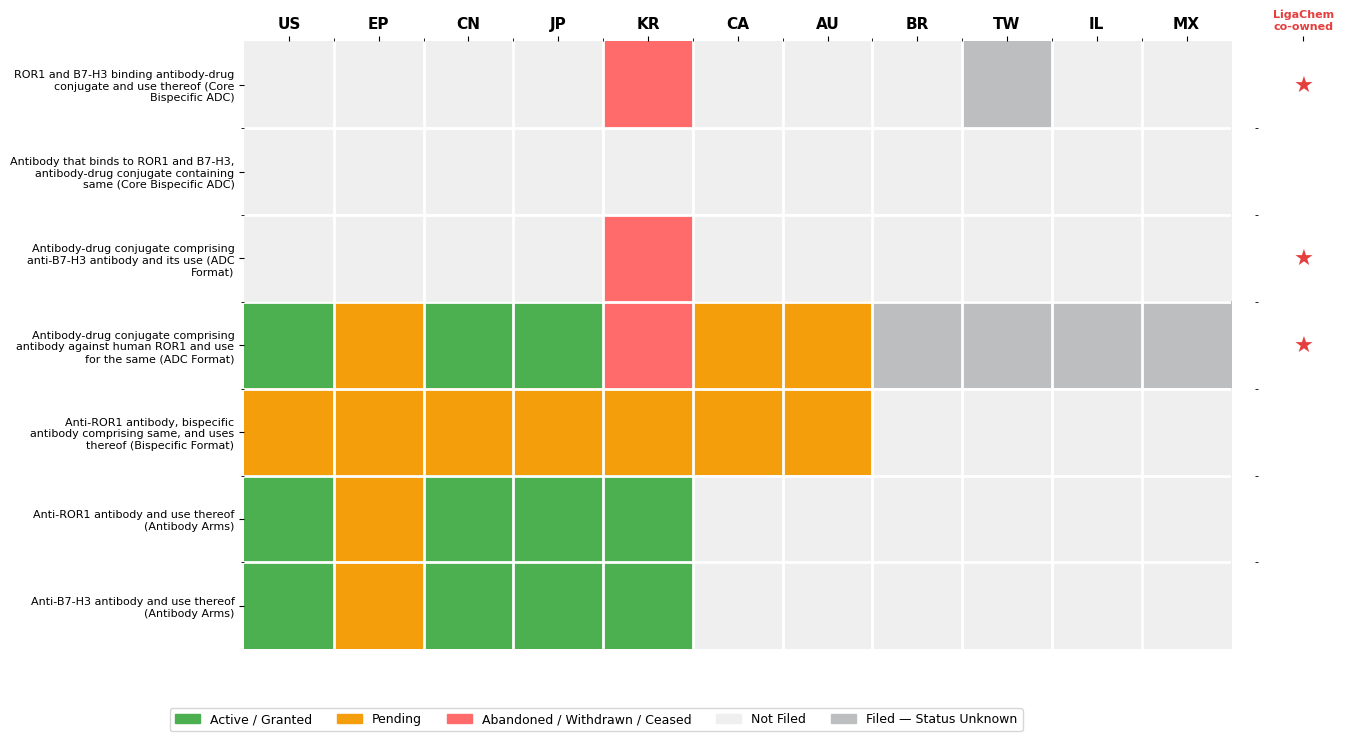

In [23]:
import textwrap
import numpy as np
from matplotlib.colors import ListedColormap

status_data = {
    'ROR1 and B7-H3 binding antibody-drug\nconjugate and use thereof\n(Core Bispecific ADC)': 
        {'US': 0, 'EP': 0, 'CN': 0, 'JP': 0, 'KR': 1, 'CA': 0, 'AU': 0, 'BR': 0, 'TW': 4, 'IL': 0, 'MX': 0, 'LigaChem': 1},
    'Antibody that binds to ROR1 and B7-H3,\nantibody-drug conjugate containing same\n(Core Bispecific ADC)': 
        {'US': 0, 'EP': 0, 'CN': 0, 'JP': 0, 'KR': 0, 'CA': 0, 'AU': 0, 'BR': 0, 'TW': 0, 'IL': 0, 'MX': 0, 'LigaChem': 0},
    'Antibody-drug conjugate comprising\nanti-B7-H3 antibody and its use\n(ADC Format)': 
        {'US': 0, 'EP': 0, 'CN': 0, 'JP': 0, 'KR': 1, 'CA': 0, 'AU': 0, 'BR': 0, 'TW': 0, 'IL': 0, 'MX': 0, 'LigaChem': 1},
    'Antibody-drug conjugate comprising antibody\nagainst human ROR1 and use for the same\n(ADC Format)': 
        {'US': 3, 'EP': 2, 'CN': 3, 'JP': 3, 'KR': 1, 'CA': 2, 'AU': 2, 'BR': 4, 'TW': 4, 'IL': 4, 'MX': 4, 'LigaChem': 1},
    'Anti-ROR1 antibody, bispecific antibody\ncomprising same, and uses thereof\n(Bispecific Format)': 
        {'US': 2, 'EP': 2, 'CN': 2, 'JP': 2, 'KR': 2, 'CA': 2, 'AU': 2, 'BR': 0, 'TW': 0, 'IL': 0, 'MX': 0, 'LigaChem': 0},
    'Anti-ROR1 antibody and use thereof\n(Antibody Arms)': 
        {'US': 3, 'EP': 2, 'CN': 3, 'JP': 3, 'KR': 3, 'CA': 0, 'AU': 0, 'BR': 0, 'TW': 0, 'IL': 0, 'MX': 0, 'LigaChem': 0},
    'Anti-B7-H3 antibody and use thereof\n(Antibody Arms)': 
        {'US': 3, 'EP': 2, 'CN': 3, 'JP': 3, 'KR': 3, 'CA': 0, 'AU': 0, 'BR': 0, 'TW': 0, 'IL': 0, 'MX': 0, 'LigaChem': 0},
}

# separate jurisdiction columns from LigaChem column
key_markets = ['US', 'EP', 'CN', 'JP', 'KR', 'CA', 'AU', 'BR', 'TW', 'IL', 'MX']
families = list(status_data.keys())
n_rows = len(families)
n_cols = len(key_markets)

# build main matrix (jurisdiction only)
matrix = np.array([[status_data[f][m] for m in key_markets] for f in families])

# ligachem column separately
ligachem_col = np.array([status_data[f]['LigaChem'] for f in families])

colors = ["#EFEFEF", '#FF6B6B', '#F59E0B', '#4CAF50', "#BCBEC0"]
cmap = ListedColormap(colors)

fig, (ax_main, ax_liga) = plt.subplots(
    1, 2,
    figsize=(16, 8),
    gridspec_kw={'width_ratios': [11, 1], 'wspace': 0.05}
)
fig.subplots_adjust(left=0.28, right=0.97, top=0.88, bottom=0.12)

# --- main heatmap ---
ax_main.imshow(matrix, cmap=cmap, aspect='auto', vmin=0, vmax=4)

ax_main.set_xticks(range(n_cols))
ax_main.set_xticklabels(key_markets, fontsize=11, fontweight='bold')
ax_main.xaxis.set_label_position('top')
ax_main.xaxis.tick_top()

ax_main.set_yticks(range(n_rows))
ax_main.set_yticklabels(
    [textwrap.fill(f, width=38) for f in families],
    fontsize=8
)

ax_main.spines[:].set_visible(False)
ax_main.set_xticks([x - 0.5 for x in range(1, n_cols)], minor=True)
ax_main.set_yticks([y - 0.5 for y in range(1, n_rows)], minor=True)
ax_main.grid(which='minor', color='white', linewidth=2)

# --- LigaChem column ---
ligachem_matrix = ligachem_col.reshape(-1, 1)

# use simple binary colormap for LigaChem: 0=white, 1=red star
ax_liga.imshow(
    np.zeros_like(ligachem_matrix),  # all white background
    cmap=ListedColormap(['white']),
    aspect='auto', vmin=0, vmax=1
)

# add star for co-owned rows
for i, val in enumerate(ligachem_col):
    if val == 1:
        ax_liga.text(0, i, '★', ha='center', va='center',
                     fontsize=16, color='#E53E3E')

ax_liga.set_xticks([0])
ax_liga.set_xticklabels(['LigaChem\nco-owned'], fontsize=8,
                         fontweight='bold', color='#E53E3E')
ax_liga.xaxis.set_label_position('top')
ax_liga.xaxis.tick_top()
ax_liga.set_yticks([])
ax_liga.spines[:].set_visible(False)
ax_liga.set_yticks([y - 0.5 for y in range(1, n_rows)], minor=True)
ax_liga.grid(which='minor', color='white', linewidth=2)

# --- legend at bottom ---
legend_patches = [
    mpatches.Patch(color='#4CAF50', label='Active / Granted'),
    mpatches.Patch(color='#F59E0B', label='Pending'),
    mpatches.Patch(color='#FF6B6B', label='Abandoned / Withdrawn / Ceased'),
    mpatches.Patch(color='#EFEFEF', label='Not Filed'),
    mpatches.Patch(color='#BCBEC0', label='Filed — Status Unknown'),
]
fig.legend(handles=legend_patches, fontsize=9,
           loc='lower center',
           bbox_to_anchor=(0.5, 0.01),
           ncol=5,
           frameon=True)

plt.show()

---

## <span style="background-color: yellow; color: black;">In-depth Analysis of the 7 Patent Claims</span>

Need to look into claims to see if actually is protecting NEOK001 asset, especially those co-filed with LigaChem; as LigaChem and ABL Bio actually co-developed another ROR1 ADC, CS5001. So these patent families may actually be unrelated to NEOK001 or have limited protection

### [TW202313122A](https://patents.google.com/patent/TW202313122A/en) - "Ror1 and b7-h3 binding antibody-drug conjugate and use thereof"
_Family 33 (from my csv row order)_

> Has 81 Claims
>
> - Claim 1 provides broad composition of matter protection over the entire class of ROR1×B7-H3 bispecific ADCs - breadth given in  linker and payload chemistry
> - Following dependent claims build layered fallback protection down to the specific CDR sequences, glucuronic acid-based cleavable linker, and site-specific farnesylation conjugation for payload 

Claim 1 mentions:
- A conjugate with structure Ab-(X)y where:
- Ab = any bispecific antibody binding both ROR1 AND B7-H3
- X = active agent + linker
- y = 1-20 (DAR)

Claims 2-8 focuses on bispecific construct
- Narrows down Ab to ROR1 and B7-H3 binding domains (bispecific)
- Specifies CDR sequences for both arms, with SEQ ID No. 1 to 19 for ROR1 arm and No. 57 to 62 for B7-H3 arm [this means different options for ROR1 arm (multiple sequences for HCDR1, HCDR2, HCDR3, LCDR1, LCDR2, LCDR3) but single set for B7-H3 arm]
- Expands further to protect sequences with >90% homology to these claimed sequenes
- Then also covers structural variations (putting a intra-antibody linker in between VH-VL domains; adding Fc region to bispecific) and also different antibody formats (like full length or a fragment of the antibody)

Claim 9 focuses on linker
- Defines the linker as glucuronic acid-based (this is not mentioned in claim 1 so the independent claim covers all linker and this is fall back in case claim 1 is invalidated)
- This resembles Synaffix's SYNtecan-E platform, so there may be license dependency here

Claim 10-53 narrow down on linker chemistry
- Specify the PEG chain length, specific attachment chemistry 
- In terms of linker-payload, there is mention of a farnesylation-based conjugation method for attaching drugs to the antibody
- Also mention of branched linker for dual-payload delivery 

Claim 54-73 focuses on Branched Dual Payloads
- Continues off the branched linker structure; where you can attach two drugs per linker attachment **(defensive patenting by claiming dual payload to prevent competitors from combining this bispecific format with dual payload system)**

Claim 74-78 focuses on the Payload (active agent)
- It is a chemotherapeutic, immunomodulator, or toxin
- Provides long list of a range of specific agents
- Also mentions and specifies Topo 1 inhibitors (which is what NEOK001 uses)

Claim 79-81 covers pharmaceutical composition and cancer indications
- Indications of "blood cancer, lung cancer, non-small cell lung cancer, gastrointestinal tract cancer, colorectal cancer, colon cancer, breast cancer, ovarian cancer, Cervical cancer, uterine cancer, prostate cancer, testicular cancer, liver cancer, kidney cancer, skin cancer, bladder cancer, pancreatic cancer, neuroblastoma, epithelial squamous cell carcinoma, thyroid cancer, head and neck cancer, adrenal gland cancer, oral cancer, bone marrow tumor, brain cancer, sarcoma, osteosarcoma, Kaposi's sarcoma, and melanoma"  

<br>

---

### [WO2021101349A1](https://patents.google.com/patent/WO2021101349A1/en?oq=WO+2021%2f101349+A1) - "Antibody that binds to ror1 and b7-h3, antibody-drug conjugate containing same, and use thereof"
_Family 29 (from my csv row order)_

> Has 8 Claims
> - Is more of a fall back for "TW202313122A" - where if it holds, get coverage of any ROR1xB7-H3 bispecific ADC regardless of sequence - but WO2021101349A1 is a fall back that protects the exact antibody sequences
> - This patent covers the exact same CDR sequences as "TW202313122A" (same SEQ ID NOs for both arms) but are actually specified directly in Claim 1, not in dependent claims
> - Makes this a narrower but harder-to-challenge patent (more defensible)
> - Only 8 claims (vs "TW202313122A"'s 81) that are focused on the antibody and ADC construct (rather than mentioning linker and payload chemistry)


Claim 1 mentions a bispecific antibody (not specifying ADC format yet) binding both ROR1 and B7-H3, with specific CDR sequences already defined in this Claim 1:
- ROR1 arm: SEQ ID NO: 1-19 (multiple variants, same as TW202313122A)
- B7-H3 arm: SEQ ID NO: 57-62 (single fixed set, same as TW202313122A)

Claims 2-4 narrows the bispecific antibody construct further
- Claim 2 specifies the exact CDR combinations → Sequences already mentioned in Claim 1 but this one is explicit about the combinations that go together
- Claim 3 extends protection to sequences with >90% homology to cover antibody sequence variants
- Claim 4 covers multiple antibody structural formats (full-length, fragments); to prevent fragment-based workarounds by competitors

Claim 5 covers the nucleic acid encoding the bispecific antibody; so the **DNA sequence that produces this antibody**
- So if another company argues against the protein claim, them making the gene construct that produces this antibody would still infringe
- Adds an additional layer of upstream protection at the molecular biology level

Claim 6 starts to specify the ADC format
- Mentions bispecific antibody conjugated to "a drug"; breadth in drug (generic)

Claim 7 narrows down the drug to specific payloads
- Provides a list of "one selected from the group consisting of pyrrolobenzodiazepine dimer (PBD), cyclopropabenzidol dimer (AB009), MMAE (Monomethyl auristatin E), and DM1"
- **Of interest for NEOK001, no mention of Topo 1 inhibitors (could be relying on Claim 6 which gives drug breadth)**

Claim 8 specifies it is a composition for preventing or treating cancer (no specific list of cancers mentioned in this patent)

<br>

---


### [KR20210063070A](https://patents.google.com/patent/KR20210063070A/en?oq=+KR+20210063070+A) - "Antibody-drug conjugate comprising anti-B7-H3 antibody and its use"
_Family 34 (from my csv row order)_

> Has 146 Claims
> - This is the B7-H3 monospecific ADC format patent, which covers an anti-B7-H3 antibody conjugated to a drug
> - Protects the B7-H3 ADC building block independently of the bispecific construct
> - Importantly, Claim 1 is structured similarly to "TW202313122A", with the ADC conjugate formula Ab-(X)y BUT here Ab is a monospecific anti-B7-H3 antibody
> - CDR sequences are specified in Claim 1 for the B7-H3 arm sequences, with SEQ ID NO: 1–29 (These sequences does have the set mentioned in TW202313122A & WO2021101349A1, and just expands it further)


Claim 1 mentioned the anti-B7-H3 ADC with structure Ab-(X)y where:
- Ab = anti-B7-H3 antibody (monospecific) with CDR sequences specified in Claim 1:
  - CDRH1: SEQ ID NO: 1–4 (4 options)
  - CDRH2: SEQ ID NO: 5–9 (5 options)
  - CDRH3: SEQ ID NO: 10–14 (5 options)
  - CDRL1: SEQ ID NO: 15–19 (5 options)
  - CDRL2: SEQ ID NO: 20–24 (5 options)
  - CDRL3: SEQ ID NO: 25–29 (5 options)
- X = active agent + linker (generic at this level)
- y = integer 1-20 (DAR range)

Claims 2–5 narrow down the CDR combinations:
- Claim 2 & 3: specifies the exact CDRH and the exact CDRL combinations
- Claim 4: specifies matched CDRH + CDRL combinations together
- Claim 5: specifies all 6 CDRs as complete matched sets → 5 complete antibody variants protected 

Claims 6-12 expands on the antibody sequence coverage:
- Claims 6–9: cover full variable region (VH, VL) and full chain sequences (heavy chain, light chain) at ≥90%. Then in the next claim, narrows this down further to ≥95% homology thresholds as a fallback
- Claim 10 specifies the antibody class isotype → adds IgG1 constant region (SEQ ID NO: 60) and lambda light chain (SEQ ID NO: 64)
- Claims 11–12 expands from Claims 2-5 by specifying the entire varaible region sequences (not just CDR loops); mentions specific VH+VL and heavy+light chain combinations

Claim 13 mentions the monoclonal antibody format

Claim 14 specifies it is a human monoclonal antibody with cross-reactivity to mouse and monkey B7-H3
- Cross-reactivity to mouse is important as it means antibody will work in preclinical mouse models
- Also mentions monkey B7-H3 which may be important for later-stage toxicology studies (primate studies before human trials)

Claims 15–18 cover antibody format variations:
- Claim 15: cleavable linker between antibody and active agent
- Claim 16: IgG1, IgG2, IgG3 or IgG4 isotypes
- Claim 17: human, mouse or monkey B7-H3 target (cross-species coverage)
- Claim 18: protects also antibody fragment formats

Claim 19 adds a linker layer 
- Defines glucuronic acid-based linker (like in "TW202313122A")

Claims 20–57 narrows down linker chemistry progressively:
- Specifies the exact chemical details of the glucuronic acid cleavable linker
- Defines site-specific conjugation via farnesylation (like in "TW202313122A"); allowing the drug to attach at one precise location on the antibody rather than randomly
- Specifies PEG (polyethylene glycol) spacer chain lengths
- Covers oxime-based ligation chemistry, another additional site-specific drug attachment strategy
- Covers branched linker architecture for dual payload delivery

Claims 58–76 further narrows down the linker chemistry:
- Covers additional click chemistry conjugation for attaching drug to antibody
- Gves a lot of detailed linker chemistry coverage

Claims 77-79 define specific linker attachment structures:
- Covers additional linker architectures outside glucuronic acid-based linker, oxime-containing linkers specifically
- **Fallback protection on the conjugation technology across many possible chemical approaches**

Claims 93–114 brings in the branched dual payload:
- Covers a branched linker architecture for two active agents per attachment at conjugation site on the antibody
- **Same defensive patenting rationale as above; prevents competitors combining B7-H3 antibody with dual payload system**

Claims 115–134 mentions the payload (active agent):
- Claims 115–117: specifies active agent broadly defined across three tiers - chemotherapeutic/toxin (claim 115), immunomodulatory/anticancer/antiviral/antifungal/antiparasitic compounds (117), and an extensive specific agent example list (118), which mentions topo I inhibitors
- Claims 119–134: specifies pyrrolobenzodiazepine (PBD) dimer in significant detail with full chemical structure definitions

Claims 135–136 are additional antibody properties:
- Claim 135 mentions the antibody can have specificity for additional antigens beyond B7-H3 (means a B7-H3 antibody that ALSO binds another target,like ROR1). Provides additional protection layer for a bispecific construct 
- Claim 136: antibody induces ADCC (antibody-dependent cellular cytotoxicity) or inhibits B7-H3 immune checkpoint → additional killing mechanism beyond payload, immunoregulatory

Claims 137–146 mentions pharmaceutical composition, kit and treatment
- Claim 137 mentions use in pharmaceutical composition
- Claims 138–140: mentions treatment of B7-H3 overexpressing cancers (solid cancers: breast, thyroid, prostate, renal, neuroblastoma, HCC, cervical, osteosarcoma, oral, bladder, glioma, NSCLC, pancreatic, gastric, ovarian, colorectal, melanoma, endometrial, head and neck, urothelial) AND hematological cancers (acute leukemia, multiple myeloma)
- Claim 141: covers combination therapy claims with checkpoint inhibitors (PD-1, PD-L1, CTLA-4, LAG-3, CD28, 4-1BB, TIM3, OX-40, TIGIT, CD47, CD73 etc.)
- Claims 143–146: mentions kit, treatment method, and use claims; covers act of treating so that even if composition claims are challenged, have this treatment method claim to provide protection for clinical use

<br>

---




### [BR112022003589A2](https://patents.google.com/patent/BR112022003589A2/en?oq=BR+112022003589+A2+) - "Antibody-drug conjugate comprising antibody against human ror1 and use therefor"
_Family 16 (from my csv row order)_

> Has 38 Claims (unable to see claims in BR submission so info below based off "[US11707533B2](https://patents.google.com/patent/US11707533B2/en?oq=BR+112022003589+A2+)")
> - Is the ROR1 monospecific ADC format patent (like KR20210063070A's role for for B7-H3, but here protecting the ROR1 ADC building block independently)
> - Claim 1 is structured like WO2021101349A1 and KR20210063070, where CDR sequences are specified directly in Claim 1 (narrower but more defensible)

Claim 1 mentions anti-ROR1 ADC with structure Ab-(X)y where:
- Ab = anti-ROR1 antibody (monospecific) with 10 specific CDR combinations defined directly in Claim 1
- X = active agent + linker (generic)
- y = integer 1-20 (DAR range)

Claims 2–5 extends on antibody sequence coverage:
- Claim 2: full heavy chain variable region (VH) sequences with ≥90% or ≥95% homology thresholds
- Claim 3: full light chain variable region (VL) sequences with ≥90% or ≥95% homology thresholds
- Claim 4: specific VH+VL combinations
- Claim 5: specific matched full heavy+light chain combinations 

Claims 6–8 cover antibody format and linker type:
- Claim 6: extensive antibody format list (that protection includes fragments, monoclonal, **bispecific, multispecific**)
- Claim 7: rabbit, mouse, chimeric, humanized, or fully human monoclonal antibody
- Claim 8: cleavable linker between antibody and active agent

Claim 9 adds a linker layer by specifically mentioning glucuronic acid-based linker

Claims 10–21 narrow further on linker chemistry:
- Progressively narrows the glucuronic acid linker chemistry from Claim 9, specifying the connection group, hydrophilic amino acid components, farnesylation-based site-specific conjugation, oxime-based attachment, and PEG spacer chain lengths
- Same progressive narrowing pattern as TW202313122A and KR20210063070A but more concise with just 12 claims

Claims 22–24 expands into branched dual payload:
- Same branched linker architecture for two active agents per attachment
- Again, see defensive patenting to prevents competitors combining ROR1 antibody with a dual payload system

Claim 25 the specific conjugate structure is mentioned
- Provides a concrete structural example of the complete ADC molecule (anti-ROR1 antibody + linker + active agent)

Claim 26 goes on to broadly define the payload
- Covers immunoregulatory compounds, anticancer, antiviral, antibacterial, antifungal, 
  antiparasitic agents

Claims 27–35 specifically mentions the payload as PBD:
- Claim 27: specifically covers ROR1 ADC + PBD dimer payload
- Claims 28–35: expands on the PBD dimer chemical structure definitions 

Claims 36–38 is the pharmaceutical composition and treatment:
- Claim 36: pharmaceutical composition, where the ADC is formulated as an actual 
  drug product for patient administration
- Claim 37: specifies method of treating diseases associated with ROR1 overexpression (method of treatment claim; covers clinical use)
- Claim 38: method of treating cancer broadly, with no specific cancer indication list

<br>

---


### [AU202330610A1](https://patents.google.com/patent/AU2023306100A1/en?oq=AU+2023%2f306100+A1) - "Anti-ror1 antibody, bispecific antibody comprising same, and uses thereof"
_Family 24 (from my csv row order)_

> Has 29 Claims
> - Covers three distinct assets within a single patent: ROR1 monospecific antibody, ROR1x4-1BB bispecific antibody (a different ABL Bio asset), and ROR1xB7-H3 bispecific antibody (relevant to NEOK001)
> - This is the **bispecific format patent**; unlike US11707533B2 which protects the ROR1 ADC conjugate, this protects the bispecific antibody construct without drug attached
> - Claim 1 is pure antibody claim (no ADC)
> - ADC component appears much later in the claims (Claim 25), making this primarily an antibody platform patent
> - CDR sequences in Claim 1 are a single fixed set for ROR1 (SEQ ID NO: 1–6)

Claims 1–8 focus on anti-ROR1 monospecific antibody:
- Claim 1 specifies it is an anti-ROR1 antibody with a single fixed CDR set (pure antibody; no drug, no linker, no conjugate)
- Claim 2 narrows it further to specific VH+VL combinations: Gives two VH and two VL options; covers two antibody variants at the full variable region level
- Claim 3 extends protection to nucleic acid encoding the anti-ROR1 antibody. Upstream DNA protection (as seen in WO2021101349A1's Claim 5); prevents competitors from making the gene construct
- Claims 4–5 mentions the pharmaceutical composition for cancer treatment using monospecific ROR1 antibody: 
    - Claim 4: anti-ROR1 antibody + excipient (breadth in cancer; generic)
    - Claim 5: narrows to cancers that express ROR1 (ROR1-expressing cancer indication explicitly mentioned)
- Claims 6–8 discusses diagnostic and detection uses: (could protect a companion diagnostic for patient selection in NEOK001 trials)
    - Claim 6: composition for detecting ROR1
    - Claim 7: composition for diagnosing cancer
    - Claim 8: narrows to ROR1-expressing cancers

Claims 9–16 bring up the other ABL Bio asset, focused on Anti-ROR1 × Anti-4-1BB bispecific antibody:
- Uses the same ROR1 arm CDRs (SEQ ID NO: 1–6) as Claim 1
- Adds in anti-4-1BB arm variants with its own CDR sequences (SEQ ID NO: 13–29) 
- Claim 10: specific VH+VL combinations for ROR1 arm 
- Claim 11: specific CDR combinations for 4-1BB arm 
- Claim 12: matched HCDR+LCDR combinations for 4-1BB arm 
- Claim 13: full VH+VL sequences for 4-1BB arm

Claim 14 extends protection to nucleic acid encoding ROR1×4-1BB bispecific

Claims 15–16 brings up pharmaceutical composition but with ROR1×4-1BB
- Claim 15: pharmaceutical composition containing ROR1×4-1BB bispecific for treating any cancer
- Claim 16: narrows to cancer that specifically expresses ROR1

Claims 17–29 go into ROR1xB7-H3 bispecific antibody (NEOK001-relevant)
- Claim 17 discusses ROR1×B7-H3 bispecific antibody:
    - Same ROR1 arm CDRs (SEQ ID NO: 1–6) as Claim 1
    - B7-H3 arm CDRs broadly defined at this level (multiple options: SEQ ID NO: 48–79 across HCDR1/2/3 and LCDR1/2/3)
    - Pure antibody claim; no drug attached
- Claims 18–21  progressively narrow both antibody arms:
    - ROR1 arm narrows to specific VH+VL sequences
    - B7-H3 arm narrows from broad CDR sequence options to more specific HCDR+LCDR combinations to full VH+VL sequences 
- Claim 22 protects the nucleic acid encoding the ROR1×B7-H3 bispecific
- Claims 23–24 discuss pharmaceutical composition for cancer treatment:
    - Claim 23: ROR1×B7-H3 bispecific + excipient (breadth)
    - Claim 24: cancer expressing ROR1, B7-H3, OR both
- Claim 25-27 starts to mention ADC 
    - Claim 25 is on ROR1×B7-H3 bispecific antibody conjugated to a cytotoxic drug (generic)
    - Claim 26 narrows it to antibody-linker-drug structure
    - Claim 27 narrows the cytotoxic drug to an anticancer agent
- Claims 28–29 is pharmaceutical composition for the ADC for cancer: Claim 28 is on ADC + excipient. Claim 2 is cancer expressing ROR1, B7-H3 OR both

<br>

---


### [US11891445B1](https://patents.google.com/patent/US11891445B1/en?oq=US+11891445+B1) - "Anti-B7-H3 antibody and use thereof"
_Family 8 (from my csv row order)_

> Has 14 Claims
> - This is the B7-H3 antibody arm patent - protects the anti-B7-H3 monospecific antibody itself
> - Forms the foundation layer of NEOK001's IP protection 
> - Pure antibody patent (no ADC, no linker, no drug; just the antibody molecule)
> - Claim 1 specifies 7 complete CDR sets

Claim 1 is on anti-B7-H3 antibody with 7 matched CDR sets 
- So 7 complete antibody variants protected, using SEQ ID NO: 1–29
- Pure antibody claim — composition of matter at the antibody level

Claims 2–3 goes into full chain sequence coverage:
- Claim 2: specific VH+VL combinations
- Claim 3: specific full heavy+light chain combinations
- So having molecule protected from CDR level to full chain level

Claims 4–7 discusses antibody format and properties:
- Claim 4: monoclonal antibody format
- Claim 5: IgG1, IgG2, IgG3, or IgG4 isotypes
- Claim 6: human, mouse, or monkey B7-H3 cross-reactivity (woud help enable direct use in preclinical mouse and primate studies without a separate surrogate antibody)
- Claim 7: Exapnds to also protect antibody fragments

Claims 8–10 is nucleic acid and cell line protection:
- Claim 8:protect nucleic acid encoding the B7-H3 antibody
- Claim 9: vector containing that polynucleotide (could be used to protect vectrs that introduce the antibody gene into cells for manufacturing)
- Claim 10: also goes on to further protect cell line transformed with that vector (Protect actual manufacturing cell line; production process)

Claim 11 mentions pharmaceutical composition

Claim 12 goes onto the method of treating B7-H3 overexpressing cancer:
- Explicitly frames B7-H3 overexpression as the therapeutic rationale
- Claim 14 extends this by mentioning that the treatment mechanism is reactivating (immunoregulatory mechanism of action; B7-H3 checkpoint blockade reactivating suppressed T cells)

Claim 13 goes into method of diagnosing B7-H3 overexpressing cancer:
- Covers using the antibody to detect B7-H3 in patient samples; Compares B7-H3 levels to a control to diagnose cancer
- Protects a diagnostic method (could help cover a companion diagnostic for NEOK001 patient selection)

<br>

---


### [US12122830B1](https://patents.google.com/patent/US12122830B1/en?oq=US+12122830+B1+) - "Anti-ROR1 antibody and use thereof"
_Family 10 (from my csv row order)_

> Has 16 Claims
> - This is the ROR1 antibody arm patent (a ROR1 counterpart to US11891445B1's B7-H3 arm)
> - Pure antibody patent (no ADC, no linker, no drug)
> - Claim 1 specifies 10 complete CDR sets (containes variants in BR112022003589A2's Claim 1, though that one protected ROR1 antibody as an ADC conjugate while US12122830B1 protects ROR1 antibody standalone)
> - Structure mirrors US11891445B1's B7-H3 almost exactly — suggests parallel drafting strategy for both antibody arms

Claim 1 is on anti-ROR1 antibody with 10 matched CDR sets 
- So 10 complete/combination antibody variants protected, using SEQ ID NOs: 1–97
- Pure antibody claim; composition of matter at antibody level

Claims 2 covers specific VH+VL combinations
- Provides complete variable region protection beyond just CDR loops

Claims 3–6 discusses antibody format and properties:
- Claim 3: monoclonal antibody format
- Claim 4: IgG1, IgG2, IgG3, or IgG4 isotypes
- Claim 5: human, mouse, or monkey ROR1 cross-reactivity (woud help enable direct use in preclinical mouse and primate studies without a separate surrogate antibody)
- Claim 6: Exapnds to also protect antibody fragments

Claims 7–9 is nucleic acid and cell line protection:
- Claim 7:protect nucleic acid encoding the ROR1 antibody
- Claim 8: vector containing that polynucleotide (could be used to protect vectrs that introduce the antibody gene into cells for manufacturing)
- Claim 9: also goes on to further protect cell line transformed with that vector (Protect actual manufacturing cell line; production process)

Claims 10–12 — pharmaceutical composition (three tiers of composition claims):
- Claim 10: antibody + excipient broadly
- Claim 11: specifically for ROR1 overexpression-related disease
- Claim 12: narrows to cancer

Claim 13 — method of detecting ROR1 in a biological sample:
- Covers using the antibody to detect ROR1 in patient samples
- Broader than US11891445B1's Claim 13, as no requirement to compare to a control, just detection of ROR1

Claim 14 — method of diagnosing ROR1 overexpressing cancer:
- Full diagnostic method with comparison to control group
- Mirrors US11891445B1 Claim 13 but for ROR1

Claims 15–16 is on method of treatment:
- Claim 15: treating ROR1 overexpression-related disease broadly
- Claim 16: narrows to cancer specifically

<br>

---


## <span style="background-color: yellow; color: black;"> In terms of Current US Protection for NEOK001 </span>
_(Based on public information, filings could be within the 18-month publication delay of patent applications and are thus unknown)_

| Layer | Family | Coverage |
|-------|--------|----------|
| Antibody Arms | F8, F10 | ✅ Protected separately (B7-H3 and ROR1 antibodies) |
| Bispecific Antibody Format | F24 | 🟡 Pending; covers bispecific antibody but ADC scope limited to Claim 25 |
| ADC Construct or Bispecific ADC Construct | F29, F33, F34 | ❌ Dead — no active protection anywhere |

<br>

> **F16 (ADC format with ROR1), that's active, mainly protecting CS5001 asset**
>  
> <u>Family 16 — ROR1 ADC (two US filings):</u>
> - US16/940,326 — Filed 2020-07-27 — Active (= US11707533B2) — expiry ~2039
> - US18/209,299 — Filed 2023-06-13 — Pending (continuation)
> This continuation is doing something very specific, it's essentially filing a product-by-process claim on a single exact molecule; CS5001 
> 
> Look at Claim 140:
> - One specific CDR set (option f- SEQ ID NOs: 4, 11, 19, 27, 35, 42) 
> - y = 2 — DAR exactly 2, not a range
> - X is a fully drawn chemical structure
> - Claim 146-147 — CVIM farnesylation conjugation (which is LigaChem's ConjuAll method)
> - Claim 148 — draws out the complete molecule structure explicitly
> - Then Claims 149-154 add specific cancer indications including CLL, DLBCL, MCL 
> 
> So in summary: Original patent was broad ROR1 ADC platform; Continuation was CS5001 specification  
>

**Family 8 — Anti-B7-H3 antibody (US11891445B1)**
- Status: Granted
- Filed: 2019-05-23
- Single US filing 

**Family 10 — Anti-ROR1 antibody (US12122830B1)**
- Status: Granted
- Filed: 2019-05-24
- Single US filing 

**Family 24 — Bispecific format (US18/993,148)**
- Status: Pending
- Filed: 2023-07-14
- Single US filing





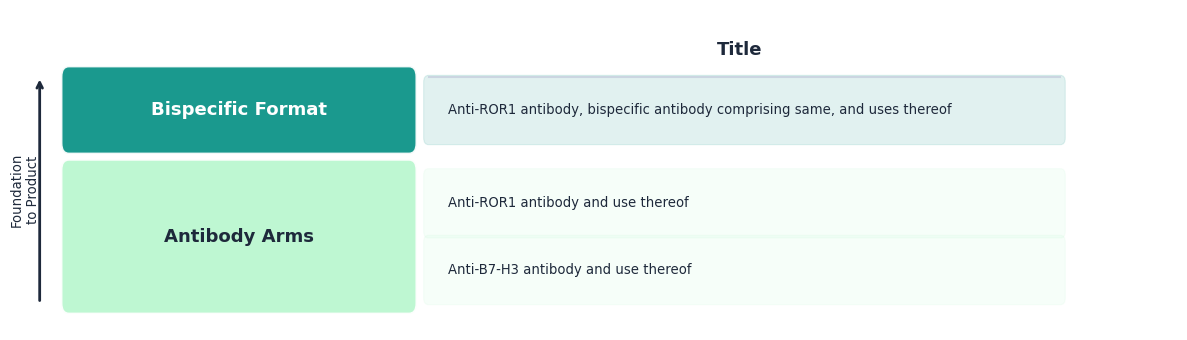

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap

NEOK_DARK =  '#0D4A47'
NEOK_MID =   '#0D7A6E'
NEOK_TEAL =  '#0D9488'
NEOK_LIME =  '#84CC16'
NEOK_LIGHT = '#BBF7D0'

layers_data = [
    ('Antibody Arms', NEOK_LIGHT,
     [('ACTIVE', 'Anti-B7-H3 antibody and use thereof'),
      ('ACTIVE', 'Anti-ROR1 antibody and use thereof')]),
    ('Bispecific Format', NEOK_TEAL,
     [('PENDING', 'Anti-ROR1 antibody, bispecific antibody comprising same, and uses thereof')]),
]

ROW_H = 0.5
GAP = 0.2
TOP = 5.5

layer_heights = [ROW_H * len(fams) for _, _, fams in layers_data]

y_positions = []
y = TOP - sum(layer_heights) - GAP * (len(layers_data) - 1)
for h in layer_heights:
    y_positions.append(y)
    y += h + GAP

y_bottom = y_positions[0] - 0.2

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.set_xlim(0, 12)
ax.set_ylim(y_bottom, 6)
ax.axis('off')

# arrow
ax.annotate('', xy=(0.3, TOP), xytext=(0.3, y_positions[0]),
            arrowprops=dict(arrowstyle='->', color='#1E293B', lw=2))
ax.text(0.15, (TOP + y_positions[0]) / 2, 'Foundation\nto Product',
        fontsize=9.5, color='#1E293B', va='center', ha='center', rotation=90)

for idx, (layer, color, families) in enumerate(layers_data):
    y = y_positions[idx]
    bar_height = layer_heights[idx]
    text_color = 'white' if color != NEOK_LIGHT else '#1E293B'

    # layer bar
    rect = mpatches.FancyBboxPatch((0.6, y), 3.5, bar_height,
                                    boxstyle="round,pad=0.08",
                                    facecolor=color, alpha=0.95,
                                    edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(2.35, y + bar_height / 2, layer,
            ha='center', va='center', fontsize=13,
            fontweight='bold', color=text_color)

    # table rows
    for k, (status, title) in enumerate(families):
        ry = y + k * ROW_H

        row_rect = mpatches.FancyBboxPatch((4.3, ry + 0.04), 6.5, ROW_H - 0.08,
                                            boxstyle="round,pad=0.05",
                                            facecolor=color, alpha=0.12,
                                            edgecolor=color, linewidth=0.8)
        ax.add_patch(row_rect)

        ax.text(4.5, ry + ROW_H/2, textwrap.fill(title, width=85),
                ha='left', va='center', fontsize=9.5, color='#1E293B')

# column header
ax.text(7.5, 5.7, 'Title', ha='center', va='center', fontsize=13,
        fontweight='bold', color='#1E293B')
ax.plot([4.3, 10.8], [5.5, 5.5], color='#CBD5E1', linewidth=1.5)

plt.tight_layout()
plt.savefig('../../data/images/05c_NEOK001_Layering.png',
            dpi=150, bbox_inches='tight', facecolor='white',
            pad_inches=0.2)  
plt.show()

### <u>**US Expiry Timeline**</u>

PTE already applied to antibody arm patents
- Both US11891445B1 and US12122830B1 have adjusted expiry dates beyond the standard 20-year term from filing  
- Means patent term adjustment (PTA) has already been applied; so the protection is longer than the base 20 years

Both granted antibody arm patents expire around 2040-2041
- Antibody arms and ROR1 ADC all expire within about a year of each other around 2040-2041.

Bispecific format pending (~2043)
- If US18/993,148 is granted, it would expire around 2043 
- Gives NEOK001 an extra 2-3 years of protection, beyond the antibody arm patents

| Application | Patent | Family | US Status | Grant Date | Adjusted Expiry |
|-------------|--------|--------|-----------|------------|-----------------|
| US17/057,646 | US11891445B1 | Anti-B7-H3 antibody and use thereof (Antibody Arms) | ✅ Active | 2024-10-22 | 2041-05-11 |
| US17/057,643 | US12122830B1 | Anti-ROR1 antibody and use thereof (Antibody Arms) | ✅ Active | 2024-02-06 | 2040-04-14 |
| US18/993,148 | US20260015418A1 | Anti-ROR1 antibody bispecific antibody comprising same (Bispecific Format) | 🟡 Pending | — | ~2043 (est.) |

**Key Takeaways:**
- Antibody arm grants secured in US through 2040-2041; composition of matter, strongest protection available
- Bispecific format pending broadly - if granted, extends runway to ~2043
- Window open now to file formulation and clinical IP before Phase 1 data disclosure

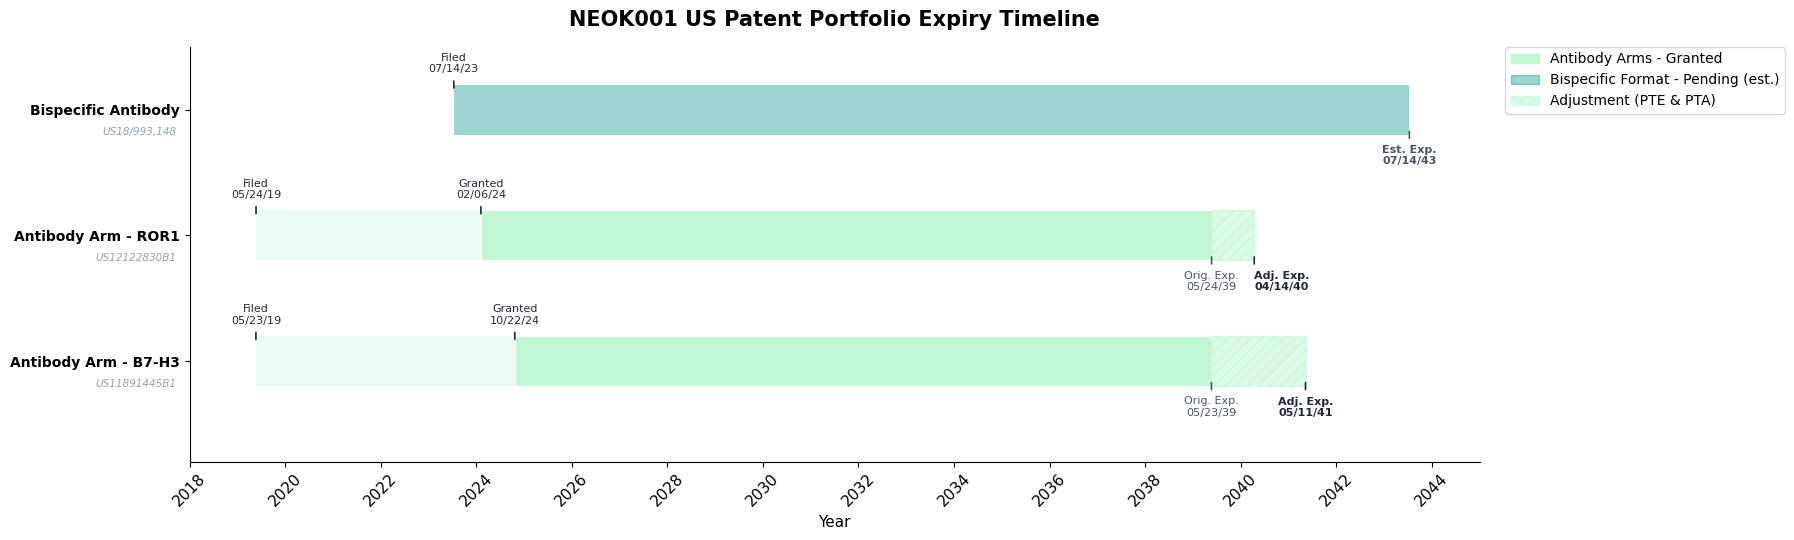

In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from datetime import datetime

NEOK_DARK =  '#0D4A47'
NEOK_MID =   '#0D7A6E'
NEOK_TEAL =  '#0D9488'
NEOK_LIGHT = '#BBF7D0'

patents = [
    {
        'label': 'Antibody Arm - B7-H3\n(US11891445B1)',
        'filed': datetime(2019, 5, 23),
        'granted': datetime(2024, 10, 22),
        'original_expiry': datetime(2039, 5, 23),
        'adjusted_expiry': datetime(2041, 5, 11),
        'status': 'granted',
        'color': NEOK_LIGHT,
        'close_labels': False,
        'adj_label_ha': 'center',
        'prosecution_alpha': 0.25,
    },
    {
        'label': 'Antibody Arm - ROR1\n(US12122830B1)',
        'filed': datetime(2019, 5, 24),
        'granted': datetime(2024, 2, 6),
        'original_expiry': datetime(2039, 5, 24),
        'adjusted_expiry': datetime(2040, 4, 14),
        'status': 'granted',
        'color': NEOK_LIGHT,
        'close_labels': False,
        'adj_label_ha': 'left',
        'prosecution_alpha': 0.25,
    },
    {
        'label': 'Bispecific Antibody\n(US18/993,148)',
        'filed': datetime(2023, 7, 14),
        'granted': None,
        'original_expiry': datetime(2043, 7, 14),
        'adjusted_expiry': datetime(2043, 7, 14),
        'status': 'pending',
        'color': NEOK_TEAL,
        'close_labels': False,
        'adj_label_ha': 'center',
        'prosecution_alpha': 0.25,
    },
]

start = datetime(2018, 1, 1)

# uniform tick geometry
TICK_ABOVE_START = 0.15
TICK_ABOVE_END   = 0.25
TICK_BELOW_START = 0.15
TICK_BELOW_END   = 0.25
LABEL_ABOVE      = 0.28
LABEL_BELOW      = 0.28

FONT_TICK   = 8
FONT_YAXIS  = 10
FONT_TITLE  = 15
FONT_XLABEL = 11
FONT_LEGEND = 10
BAR_HEIGHT  = 0.4

fig, ax = plt.subplots(figsize=(18, 5.5))
fig.subplots_adjust(left=0.30, right=0.88, top=0.88, bottom=0.15)

for i, p in enumerate(patents):
    close_labels = p.get('close_labels', False)

    if p['status'] == 'pending':
        ax.barh(i, (p['adjusted_expiry'] - p['filed']).days,
                left=mdates.date2num(p['filed']),
                height=BAR_HEIGHT, color=p['color'], alpha=0.4,
                edgecolor='none')

        # filed tick above
        ax.annotate('',
                    xy=(mdates.date2num(p['filed']), i + TICK_ABOVE_START),
                    xytext=(mdates.date2num(p['filed']), i + TICK_ABOVE_END),
                    arrowprops=dict(arrowstyle='-', color='#1E293B', lw=1.2))
        ax.text(mdates.date2num(p['filed']), i + LABEL_ABOVE,
                'Filed\n' + p['filed'].strftime('%m/%d/%y'),
                ha='center', va='bottom', fontsize=FONT_TICK, color='#1E293B')

        # est expiry tick below
        ax.annotate('',
                    xy=(mdates.date2num(p['adjusted_expiry']), i - TICK_BELOW_START),
                    xytext=(mdates.date2num(p['adjusted_expiry']), i - TICK_BELOW_END),
                    arrowprops=dict(arrowstyle='-', color='#475569', lw=1.2))
        ax.text(mdates.date2num(p['adjusted_expiry']), i - LABEL_BELOW,
                'Est. Exp.\n' + p['adjusted_expiry'].strftime('%m/%d/%y'),
                ha='center', va='top', fontsize=FONT_TICK, color='#475569',
                fontweight='bold')

    else:
        # prosecution period
        ax.barh(i, (p['granted'] - p['filed']).days,
                left=mdates.date2num(p['filed']),
                height=BAR_HEIGHT, color=p['color'],
                alpha=p['prosecution_alpha'],
                edgecolor='none')

        # main patent term
        ax.barh(i, (p['original_expiry'] - p['granted']).days,
                left=mdates.date2num(p['granted']),
                height=BAR_HEIGHT, color=p['color'], alpha=0.9,
                edgecolor='white', linewidth=1)

        # PTE extension
        if p['adjusted_expiry'] > p['original_expiry']:
            ax.barh(i, (p['adjusted_expiry'] - p['original_expiry']).days,
                    left=mdates.date2num(p['original_expiry']),
                    height=BAR_HEIGHT, color=p['color'], alpha=0.5,
                    edgecolor=p['color'], linewidth=1,
                    hatch='///')

        # filed tick above
        ax.annotate('',
                    xy=(mdates.date2num(p['filed']), i + TICK_ABOVE_START),
                    xytext=(mdates.date2num(p['filed']), i + TICK_ABOVE_END),
                    arrowprops=dict(arrowstyle='-', color='#1E293B', lw=1.2))
        ax.text(mdates.date2num(p['filed']), i + LABEL_ABOVE,
                'Filed\n' + p['filed'].strftime('%m/%d/%y'),
                ha='center', va='bottom', fontsize=FONT_TICK, color='#1E293B')

        # granted tick above
        ax.annotate('',
                    xy=(mdates.date2num(p['granted']), i + TICK_ABOVE_START),
                    xytext=(mdates.date2num(p['granted']), i + TICK_ABOVE_END),
                    arrowprops=dict(arrowstyle='-', color='#1E293B', lw=1.2))
        ax.text(mdates.date2num(p['granted']), i + LABEL_ABOVE,
                'Granted\n' + p['granted'].strftime('%m/%d/%y'),
                ha='center', va='bottom', fontsize=FONT_TICK, color='#1E293B')

        # original expiry tick below
        orig_ha = 'right' if close_labels else 'center'
        ax.annotate('',
                    xy=(mdates.date2num(p['original_expiry']), i - TICK_BELOW_START),
                    xytext=(mdates.date2num(p['original_expiry']), i - TICK_BELOW_END),
                    arrowprops=dict(arrowstyle='-', color='#475569', lw=1.2))
        ax.text(mdates.date2num(p['original_expiry']), i - LABEL_BELOW,
                'Orig. Exp.\n' + p['original_expiry'].strftime('%m/%d/%y'),
                ha=orig_ha, va='top', fontsize=FONT_TICK, color='#475569')

        # adjusted expiry tick below
        ax.annotate('',
                    xy=(mdates.date2num(p['adjusted_expiry']), i - TICK_BELOW_START),
                    xytext=(mdates.date2num(p['adjusted_expiry']), i - TICK_BELOW_END),
                    arrowprops=dict(arrowstyle='-', color='#1E293B', lw=1.2))
        ax.text(mdates.date2num(p['adjusted_expiry']), i - LABEL_BELOW,
                'Adj. Exp.\n' + p['adjusted_expiry'].strftime('%m/%d/%y'),
                ha=p['adj_label_ha'], va='top', fontsize=FONT_TICK,
                color='#1E293B', fontweight='bold')

        # PTE label
        if p['adjusted_expiry'] > p['original_expiry']:
            mid_pte = mdates.date2num(p['original_expiry']) + \
                      (mdates.date2num(p['adjusted_expiry']) -
                       mdates.date2num(p['original_expiry'])) / 2

# y axis — just replace the set_yticklabels line with:
ax.set_yticks(range(len(patents)))
ax.set_yticklabels([p['label'].split('\n')[0].split('(')[0].strip() 
                    for p in patents], fontsize=FONT_YAXIS, fontweight='bold')
# then add patent numbers as secondary text below each label
for i, p in enumerate(patents):
    # extract patent number from label (text in parentheses)
    import re
    match = re.search(r'\((US[\w/,]+)', p['label'])
    if match:
        patent_num = match.group(1)
        ax.text(-0.01, i - 0.18, patent_num,
                transform=ax.get_yaxis_transform(),
                ha='right', va='center',
                fontsize=7.5, color='#94A3B8',
                style='italic')

# x axis
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlim(mdates.date2num(start), mdates.date2num(datetime(2045, 1, 1)))
ax.tick_params(axis='x', rotation=45, labelsize=FONT_XLABEL)
ax.set_ylim(-0.8, len(patents) - 0.5)

ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel('Year', fontsize=FONT_XLABEL)
ax.set_title('NEOK001 US Patent Portfolio Expiry Timeline',
             fontsize=FONT_TITLE, fontweight='bold', pad=15)

legend_patches = [
    mpatches.Patch(color=NEOK_LIGHT, alpha=0.9, label='Antibody Arms - Granted'),
    mpatches.Patch(color=NEOK_TEAL,  alpha=0.4, label='Bispecific Format - Pending (est.)'),
    mpatches.Patch(color=NEOK_LIGHT, alpha=0.5,
                   label='Adjustment (PTE & PTA)', hatch='///'),
]
ax.legend(handles=legend_patches, fontsize=FONT_LEGEND,
          bbox_to_anchor=(1.02, 1), loc='upper left',
          borderaxespad=0, frameon=True)

plt.tight_layout()
plt.savefig('../../data/images/05c_NEOK001_US_Expiry.png',
            dpi=150, bbox_inches='tight', facecolor='white',
            pad_inches=0.2)  
plt.show()